In [ ]:
pip install kaggle

In [ ]:
pip install plotly

#Libraries

In [3]:
import pandas as pd
import os
import seaborn as sns
import numpy as np

In [4]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

In [5]:
import plotly.express as px

In [6]:
import statistics

In [7]:
import kagglehub

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
from scipy.stats import skew, kurtosis, shapiro, normaltest, chi2_contingency, pointbiserialr

In [10]:
from IPython.display import display

## Model

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score, learning_curve
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve
from sklearn import tree


# Dataset upload

In [12]:
# Download latest version
path = kagglehub.dataset_download("amitvkulkarni/lifestyle-factors-influencing-osteoporosis")

print("Path to dataset files:", path)

100%|██████████| 25.2k/25.2k [00:00<00:00, 9.57MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/amitvkulkarni/lifestyle-factors-influencing-osteoporosis/versions/2


In [13]:
df_original = pd.read_csv(os.path.join(path, "osteoporosis.csv"))

In [14]:
df = df_original.copy()

#Dataset Description

### Genaral view about osteoporosis

Osteoporosis represents a unique challenge in modern healthcare due to its asymptomatic progression until catastrophic events occur. Unlike acute conditions that prompt immediate medical attention through obvious symptoms, osteoporosis earned its moniker as the "silent disease" due to its stealthy progression. Patients often remain unaware of their condition until a sudden fracture reveals the extensive bone deterioration that has occurred over years or decades.



In [15]:
# Show the number of rows and columns
print(f"Number of rows and columns (df.shape): {df.shape}")

# Show the column names
print(f"Column names (df.columns):\n{df.columns}\n")

# Print dataset info (non-null count, dtypes, etc.)
print("Dataset info (df.info()):")
df.info()

# Show the data types of the columns
print("\nData types of columns (df.dtypes):")
print(df.dtypes)


Number of rows and columns (df.shape): (1958, 16)
Column names (df.columns):
Index(['Id', 'Age', 'Gender', 'Hormonal Changes', 'Family History',
       'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis'],
      dtype='object')

Dataset info (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-nul

In [16]:
for col in df.columns:
    print(f"Feature: {col}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)


Feature: Id
Id
1734616    1
1457264    1
1124704    1
1671682    1
1267069    1
          ..
1559220    1
1314117    1
1941095    1
1801087    1
1282963    1
Name: count, Length: 1958, dtype: int64
----------------------------------------
Feature: Age
Age
18    152
19    147
34    121
29    118
21    117
     ... 
88      9
60      8
28      8
58      7
48      6
Name: count, Length: 73, dtype: int64
----------------------------------------
Feature: Gender
Gender
Male      992
Female    966
Name: count, dtype: int64
----------------------------------------
Feature: Hormonal Changes
Hormonal Changes
Normal            981
Postmenopausal    977
Name: count, dtype: int64
----------------------------------------
Feature: Family History
Family History
No     998
Yes    960
Name: count, dtype: int64
----------------------------------------
Feature: Race/Ethnicity
Race/Ethnicity
African American    681
Caucasian           646
Asian               631
Name: count, dtype: int64
------------------

Dataset Description: Lifestyle Factors Influencing Osteoporosis

This dataset contains information on various demographic factors, lifestyle habits, and medical conditions for **1,958** individuals, aiming to study how these variables correlate with the presence of osteoporosis.

---

## 1. General Overview
- **Number of rows (observations):** 1,958  
- **Number of columns (variables):** 16  
- **Dataset topic:** Lifestyle factors potentially influencing osteoporosis development.  
- **Target variable:** **Osteoporosis** (binary: 0 = absence, 1 = presence)  
- **Main goal:** Understand the relationship between personal characteristics (age, gender, ethnicity, etc.) and lifestyle habits (smoking, alcohol consumption, physical activity, etc.) with an osteoporosis diagnosis.

---

## 2. Variable Descriptions

1. **Id**  
   - **Type:** Numeric (identifier).  

2. **Age**  
   - **Type:** Numeric (age in years).  
   - Unique values: 73 distinct ages, ranging from 18 to 90.  

3. **Gender**  
   - **Type:** Categorical (binary).  
   - Values: “Male” (992) and “Female” (966).

4. **Hormonal Changes**  
   - **Type:** Categorical (binary).  
   - Values: “Normal” (981) and “Postmenopausal” (977).

5. **Family History**  
   - **Type:** Categorical (binary).  
   - Values: “No” (998) and “Yes” (960).

6. **Race/Ethnicity**  
   - **Type:** Categorical (3 categories).  
   - Values: “African American” (681), “Caucasian” (646), “Asian” (631).

7. **Body Weight**  
   - **Type:** Categorical (binary).  
   - Values: “Normal” (1,027) and “Underweight” (931).

8. **Calcium Intake**  
   - **Type:** Categorical (binary).  
   - Values: “Low” (1,004) and “Adequate” (954).

9. **Vitamin D Intake**  
   - **Type:** Categorical (binary).  
   - Values: “Sufficient” (1,011), “Insufficient” (947).

10. **Physical Activity**  
    - **Type:** Categorical (binary).  
    - Values: “Active” (1,021), “Sedentary” (937).

11. **Smoking**  
    - **Type:** Categorical (binary).  
    - Values: “Yes” (982), “No” (976).

12. **Alcohol Consumption**  
    - **Type:** Categorical (with missing values).  
    - Values: “Moderate” (970), NaN (988).  
    - **Missing values:** 988 records.

13. **Medical Conditions**  
    - **Type:** Categorical (with missing values).  
    - Values: “Hyperthyroidism” (678), “Rheumatoid Arthritis” (633), NaN (647).  
    - **Missing values:** 647 records.

14. **Medications**  
    - **Type:** Categorical (with missing values).  
    - Values: “Corticosteroids” (973), NaN (985).  
    - **Missing values:** 985 records.

15. **Prior Fractures**  
    - **Type:** Categorical (binary).  
    - Values: “Yes” (983), “No” (975).

16. **Osteoporosis**  
    - **Type:** Binary.  
    - Values: 1 (979), 0 (979).  
    - **Distribution:** Exactly balanced (50% - 50%).



# Data Preparation

## Missing values

The missing values identified in the dataset are not true missing values,
but rather indicate the absence of specific information. Specifically:
- For the variable *Alcohol Consumption*, they indicate no alcohol consumption.
- For the variable *Medications*, they indicate that patients do not take any medications.
- For the variable *Medical Conditions*, they indicate no pre-existing medical conditions.

Therefore, we will replace the null values in these variables with the string "None"
to accurately reflect the meaning of the data.


In [17]:
# Replace null values with 'None' for the specified columns
columns_to_replace = ["Alcohol Consumption", "Medications", "Medical Conditions"]

# Iterate over the columns and replace null values with 'None'
for column in columns_to_replace:
    if column in df.columns:
        df[column] = df[column].fillna("None")

print("Null values have been replaced with 'None' for the specified variables.")
print(df[columns_to_replace].head())


Null values have been replaced with 'None' for the specified variables.
  Alcohol Consumption      Medications    Medical Conditions
0            Moderate  Corticosteroids  Rheumatoid Arthritis
1                None             None                  None
2            Moderate  Corticosteroids       Hyperthyroidism
3                None  Corticosteroids  Rheumatoid Arthritis
4                None             None  Rheumatoid Arthritis


## Column drop

In [18]:
# Drop the 'Id' column from the dataset
if "Id" in df.columns:
    df = df.drop(columns=["Id"])
    print("'Id' column has been removed from the dataset.")
else:
    print("'Id' column is not present in the dataset.")

# Display the first few rows of the updated dataset
print(df.head())


'Id' column has been removed from the dataset.
   Age  Gender Hormonal Changes Family History    Race/Ethnicity  Body Weight  \
0   69  Female           Normal            Yes             Asian  Underweight   
1   32  Female           Normal            Yes             Asian  Underweight   
2   89  Female   Postmenopausal             No         Caucasian       Normal   
3   78  Female           Normal             No         Caucasian  Underweight   
4   38    Male   Postmenopausal            Yes  African American       Normal   

  Calcium Intake Vitamin D Intake Physical Activity Smoking  \
0            Low       Sufficient         Sedentary     Yes   
1            Low       Sufficient         Sedentary      No   
2       Adequate       Sufficient            Active      No   
3       Adequate     Insufficient         Sedentary     Yes   
4            Low       Sufficient            Active     Yes   

  Alcohol Consumption    Medical Conditions      Medications Prior Fractures  \
0      

## Unlogical rows

In [19]:
# Identify inconsistencies in the dataset
inconsistent_rows = []

# Check for postmenopausal females under 30
condition_female_under_30 = (df['Gender'] == 'Female') & (df['Age'] < 30) & (df['Hormonal Changes'] == 'Postmenopausal')
inconsistent_rows.append(df[condition_female_under_30])

# Check for postmenopausal males under 40
condition_male_under_40 = (df['Gender'] == 'Male') & (df['Age'] < 40) & (df['Hormonal Changes'] == 'Postmenopausal')
inconsistent_rows.append(df[condition_male_under_40])

# Check for negative age values
condition_negative_age = (df['Age'] < 0)
inconsistent_rows.append(df[condition_negative_age])

# Combine all inconsistent rows
inconsistent_rows_df = pd.concat(inconsistent_rows)

# Display inconsistent rows
print("Inconsistent Rows Identified:")
print(inconsistent_rows_df)

# Remove inconsistent rows from the dataset
df_cleaned = df.drop(inconsistent_rows_df.index)

print("Cleaned Dataset:")
print(df_cleaned.head())


Inconsistent Rows Identified:
      Age  Gender Hormonal Changes Family History    Race/Ethnicity  \
12     19  Female   Postmenopausal            Yes             Asian   
54     23  Female   Postmenopausal            Yes             Asian   
81     25  Female   Postmenopausal            Yes             Asian   
84     25  Female   Postmenopausal            Yes         Caucasian   
94     29  Female   Postmenopausal            Yes  African American   
...   ...     ...              ...            ...               ...   
1944   21    Male   Postmenopausal             No  African American   
1946   22    Male   Postmenopausal            Yes             Asian   
1948   25    Male   Postmenopausal             No             Asian   
1952   23    Male   Postmenopausal             No         Caucasian   
1956   25    Male   Postmenopausal             No  African American   

      Body Weight Calcium Intake Vitamin D Intake Physical Activity Smoking  \
12    Underweight            Low     I

## Encode dataset

### Label Encoder

In our project, it is essential to encode the categorical variables in the dataset to make them compatible with machine learning models. These models primarily work with numerical data and cannot directly interpret categorical data as strings. Therefore, variables such as `Gender`, `Race/Ethnicity`, or `Smoking` need to be transformed into numerical values while preserving their original information.

To achieve this, we use the `LabelEncoder`, a simple and effective tool for encoding categorical variables. The `LabelEncoder` assigns a unique integer to each category in a variable. For example:
- The variable `Gender`, which contains the categories "Male" and "Female", will be transformed into the values 1 and 0, respectively.
- For a variable with more than two categories, such as `Race/Ethnicity`, each category (e.g., "African American", "Caucasian", "Asian") will be encoded with a different number, such as 0, 1, and 2.

This type of encoding is particularly useful because it preserves the distinctions between categories without introducing any ordinal relationships (i.e., it does not imply that one category is "greater" or "less" than another). Additionally, the `LabelEncoder` is quick to apply and well-integrated into preprocessing workflows, making it an ideal choice for transforming data efficiently.

By adopting this technique, we can standardize the dataset and prepare it for analysis using machine learning algorithms, ensuring that all variables are in a numerical format suitable for processing.


In [20]:
# Create a copy of the dataset for encoding
df_encoded = df_cleaned.copy()

# Identify categorical columns (of type 'object')
categorical_cols = [col for col in df_encoded.columns if df_encoded[col].dtype == 'object']

# Create a dictionary to store label mappings for each categorical column
label_mappings = {}

# Apply label encoding to the copied dataset and save mappings
for column in categorical_cols:
    label_encoder = LabelEncoder()
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])
    # Save the mapping of labels to their original values
    label_mappings[column] = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

# Convert the mappings to a DataFrame for display
mappings_df = pd.DataFrame([
    {"Column": col, "Category": k, "Label": v}
    for col, mapping in label_mappings.items()
    for k, v in mapping.items()
])

# Display the mappings DataFrame
display(mappings_df)


,Column,Category,Label
0,Gender,Female,0
1,Gender,Male,1
2,Hormonal Changes,Normal,0
3,Hormonal Changes,Postmenopausal,1
4,Family History,No,0
5,Family History,Yes,1
6,Race/Ethnicity,African American,0
7,Race/Ethnicity,Asian,1
8,Race/Ethnicity,Caucasian,2
9,Body Weight,Normal,0


# Plot

In [ ]:
fig=px.histogram(df_cleaned,x='Age',color='Osteoporosis')
fig.show()

Mode: 34
count    1406.000000
mean       45.044097
std        22.314307
min        18.000000
25%        25.000000
50%        38.000000
75%        65.000000
max        90.000000
Name: Age, dtype: float64


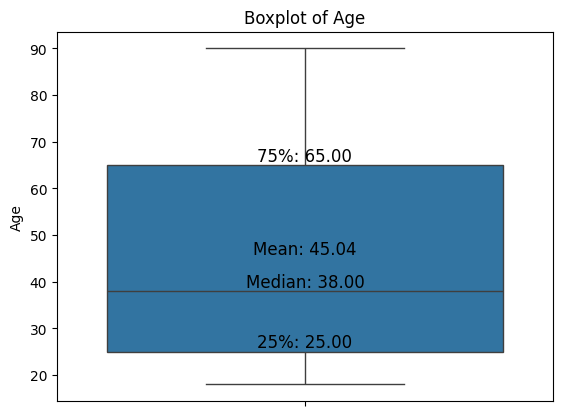

In [25]:

# Descriptive statistics for age
print(f"Mode: {statistics.mode(df_cleaned['Age'])}")  # Mode
print(df_cleaned['Age'].describe())

# boxplot
sns.boxplot(df_cleaned['Age'])

# study mean median max min std q1 q3 for age ( in general )
q25 = df_cleaned['Age'].quantile(0.25)  # 25th percentile
median = df_cleaned['Age'].median()  # Median
mean = df_cleaned['Age'].mean()  # Mean
q75 = df_cleaned['Age'].quantile(0.75)  # 75th percentile

#------------------------------------------------------------------------------------------------------------------------

# Annotate the plot with these values
plt.text(0, q25, f'25%: {q25:.2f}', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black')
plt.text(0, median, f'Median: {median:.2f}', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black')
plt.text(0, mean, f'Mean: {mean:.2f}', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black')
plt.text(0, q75, f'75%: {q75:.2f}', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black')

# Set the title
plt.title('Boxplot of Age')

# Show the plot
plt.show()

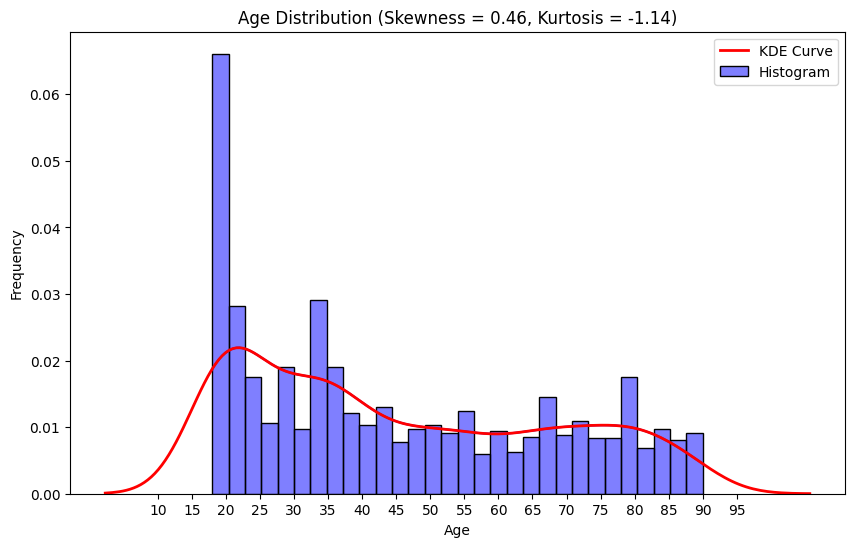

In [26]:
# Calculate skewness and kurtosis
age_skewness = skew(df_cleaned['Age'])
age_kurtosis = kurtosis(df_cleaned['Age'], fisher=True)  # Fisher=True gives us excess kurtosis but I dont know what it exactly mean ☺

#------------------------------------------------------------------------------------------------------------------------

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Age'], kde=True, color='blue', bins=30, stat="density", label="Histogram")
sns.kdeplot(df_cleaned['Age'], color='red', linewidth=2, label='KDE Curve')

decades = np.arange(10, 100, 5)  # adjust the range in x axis
plt.xticks(decades)

#------------------------------------------------------------------------------------------------------------------------

# titles and labels
plt.title(f'Age Distribution (Skewness = {age_skewness:.2f}, Kurtosis = {age_kurtosis:.2f})')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()


the boxplot charts for individuals with and without osteoporosis.( studying Age )

<ipython-input-27-e4751c7dca97>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Osteoporosis', y='Age', data=df_cleaned, palette="pastel")


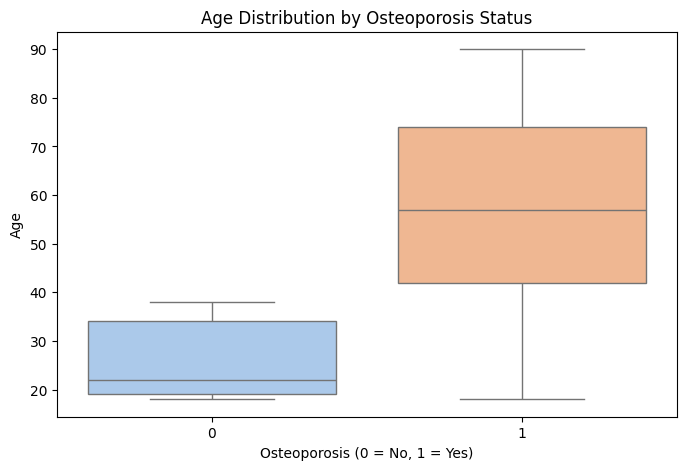

In [27]:
# Plot age distribution by osteoporosis status
plt.figure(figsize=(8, 5))
sns.boxplot(x='Osteoporosis', y='Age', data=df_cleaned, palette="pastel")
plt.title('Age Distribution by Osteoporosis Status')
plt.xlabel('Osteoporosis (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

q25 = df_cleaned['Age'].quantile(0.25)  # 25th percentile
median = df_cleaned['Age'].median()
mean = df_cleaned['Age'].mean()
q75 = df_cleaned['Age'].quantile(0.75)  # 75th percentile

In [27]:
#Here I want to check if it is normal in each case or not


osteoporosis_df_cleaned = df_cleaned[df_cleaned['Osteoporosis'] == 1] #first I assign it 0 and then change it to 1 to check in both cases

# Shapiro-Wilk Test (A Statistical Testing for Normality)
stat, p_value = shapiro(osteoporosis_df_cleaned['Age'])
print("Shapiro-Wilk Test: Statistic =", stat, ", p-value =", p_value)

#------------------------------------------------------------------------------------------------------------------------

# Skewness and Kurtosis
data_skewness = skew(osteoporosis_df_cleaned['Age'])
data_kurtosis = kurtosis(osteoporosis_df_cleaned['Age'])
print(f"Skewness: {data_skewness}")
print(f"Kurtosis: {data_kurtosis}")

print("_____________________________________________________________________________________________")

#------------------------------------------------------------------------------------------------------------------------

# Normal Test (Another Statistical Testing for Normality)
print(normaltest(osteoporosis_df_cleaned['Age']))


Shapiro-Wilk Test: Statistic = 0.9641232464867878 , p-value = 8.475709732128073e-14
Skewness: -0.19056225165185894
Kurtosis: -1.0140129456586937
_____________________________________________________________________________________________
NormaltestResult(statistic=203.2008075558059, pvalue=7.50767181826395e-45)


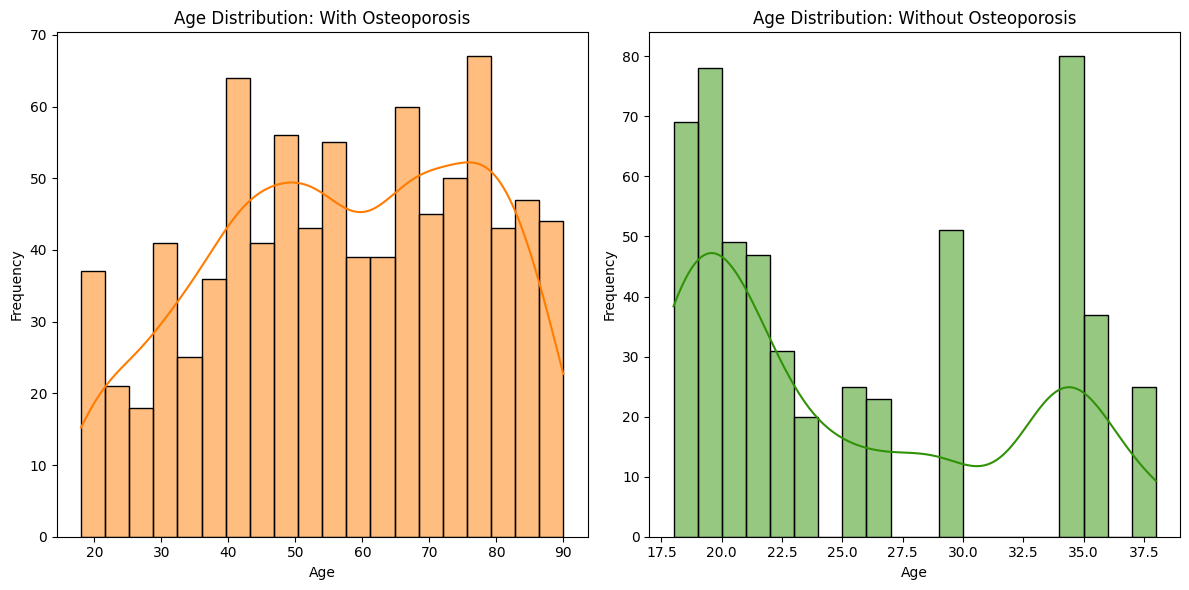

In [28]:
# Filtering the data based on the target variable
osteoporosis_1 = df_cleaned[df_cleaned['Osteoporosis'] == 1]
osteoporosis_0 = df_cleaned[df_cleaned['Osteoporosis'] == 0]

# Plot sidt by side bar charts
plt.figure(figsize=(12, 6))

#------------------------------------------------------------------------------------------------------------------------
# Distribution when osteoporosis = 0
plt.subplot(1, 2, 2)
sns.histplot(osteoporosis_0['Age'], kde=True, bins=20,  color='#2F9207')
plt.title('Age Distribution: Without Osteoporosis')
plt.xlabel('Age')
plt.ylabel('Frequency')

#------------------------------------------------------------------------------------------------------------------------

# Distribution for osteoporosis = 1
plt.subplot(1, 2, 1)
sns.histplot(osteoporosis_1['Age'], kde=True, bins=20,  color='#FF7C00')
plt.title('Age Distribution: With Osteoporosis')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [29]:
# studu mean median max min std q1 q3 for age ( in each condition 0/1 )
statistics = df_cleaned.groupby("Osteoporosis")["Age"].agg(
    Mean="mean",
    Mode=lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    Median="median",
    Min="min",
    Max="max",
    std="std",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

print(statistics)

                   Mean  Mode  Median  Min  Max        std    Q1    Q3
Osteoporosis                                                          
0             25.233645    34    22.0   18   38   6.667574  19.0  34.0
1             57.212400    79    57.0   18   90  19.679025  42.0  74.0


In [30]:
import scipy.stats as stats

# Split the dataset into two groups based on Osteoporosis
group_0 = df_cleaned[df_cleaned['Osteoporosis'] == 0]['Age']  # Age values for Osteoporosis = 0
group_1 = df_cleaned[df_cleaned['Osteoporosis'] == 1]['Age']  # Age values for Osteoporosis = 1


# Perform a Mann-Whitney U test (non-parametric alternative)
u_stat, p_value_mannwhitney = stats.mannwhitneyu(group_0, group_1, alternative='two-sided')


print("\nMann-Whitney U Test:")
print(f"U-Statistic: {u_stat:.2f}, P-Value: {p_value_mannwhitney:.4f}")
if p_value_mannwhitney < 0.05:
    print("The relationship between Age and Osteoporosis is significant (Mann-Whitney U Test).")
else:
    print("No significant relationship between Age and Osteoporosis (Mann-Whitney U Test).")



Mann-Whitney U Test:
U-Statistic: 33205.00, P-Value: 0.0000
The relationship between Age and Osteoporosis is significant (Mann-Whitney U Test).



Gender Distribution:
Gender
Female    716
Male      690
Name: count, dtype: int64


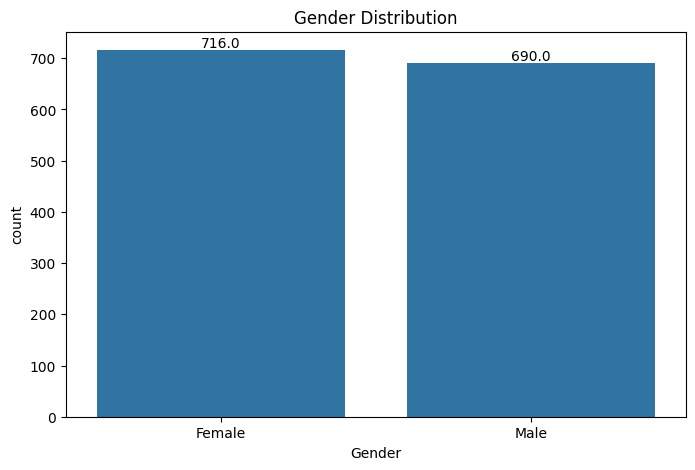


Hormonal Changes Distribution:
Hormonal Changes
Normal            981
Postmenopausal    425
Name: count, dtype: int64


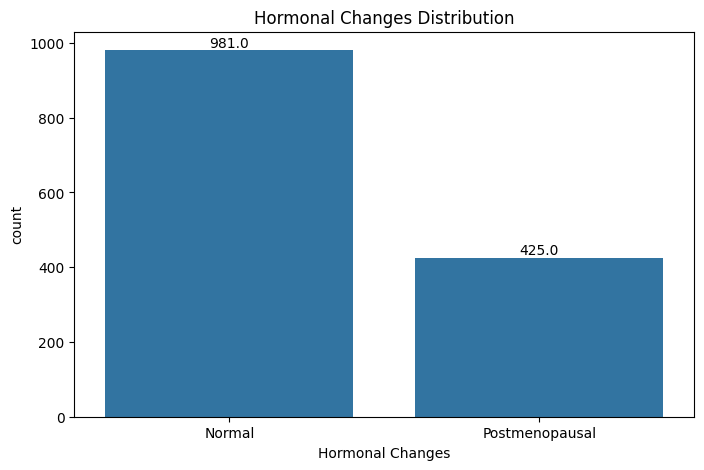


Family History Distribution:
Family History
No     725
Yes    681
Name: count, dtype: int64


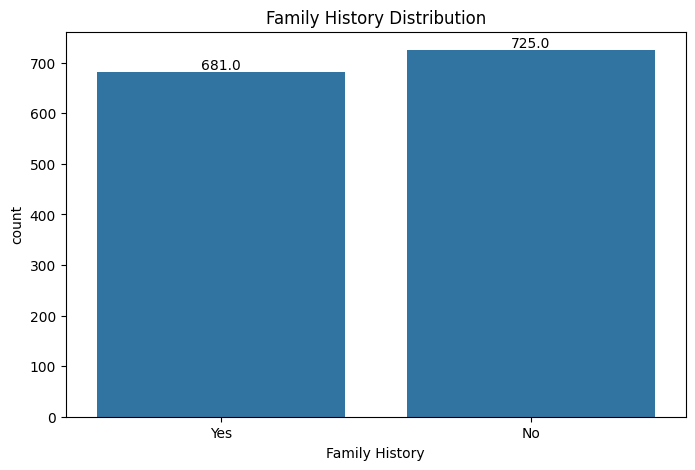


Body Weight Distribution:
Body Weight
Normal         730
Underweight    676
Name: count, dtype: int64


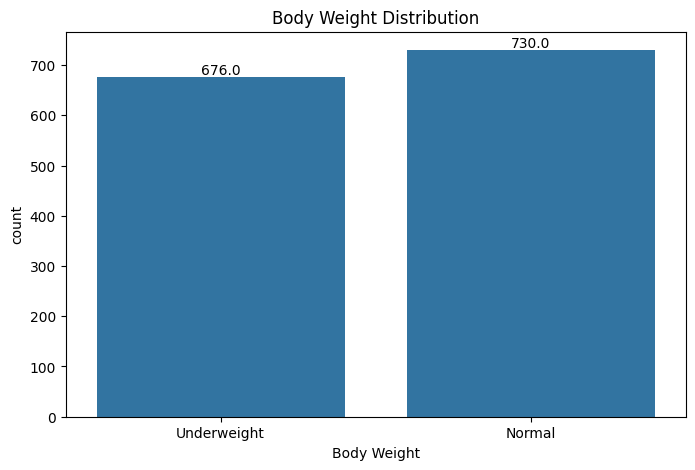


Calcium Intake Distribution:
Calcium Intake
Low         727
Adequate    679
Name: count, dtype: int64


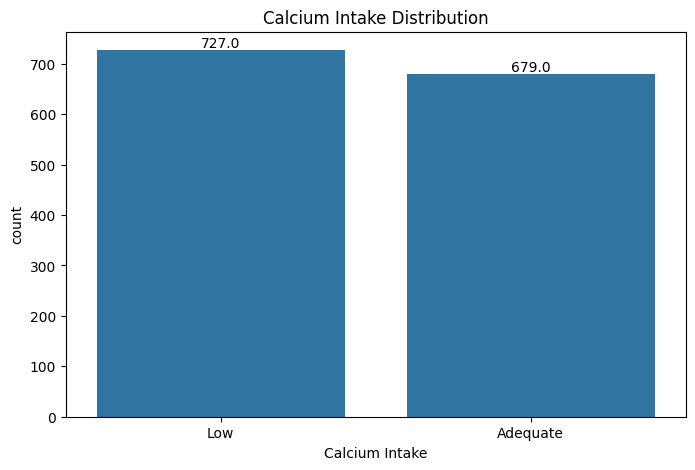


Vitamin D Intake Distribution:
Vitamin D Intake
Sufficient      733
Insufficient    673
Name: count, dtype: int64


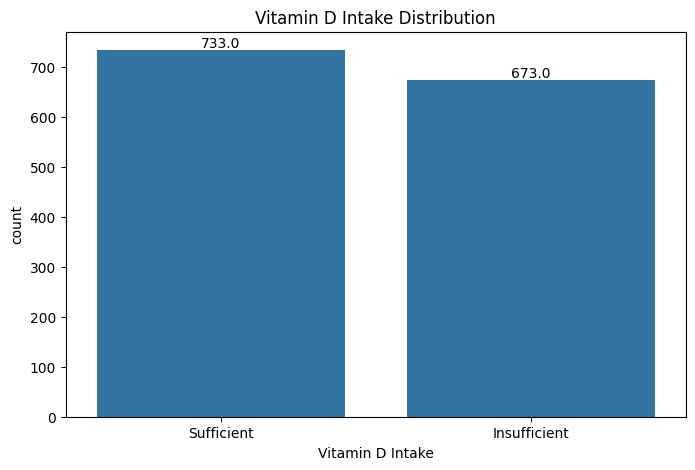


Physical Activity Distribution:
Physical Activity
Active       731
Sedentary    675
Name: count, dtype: int64


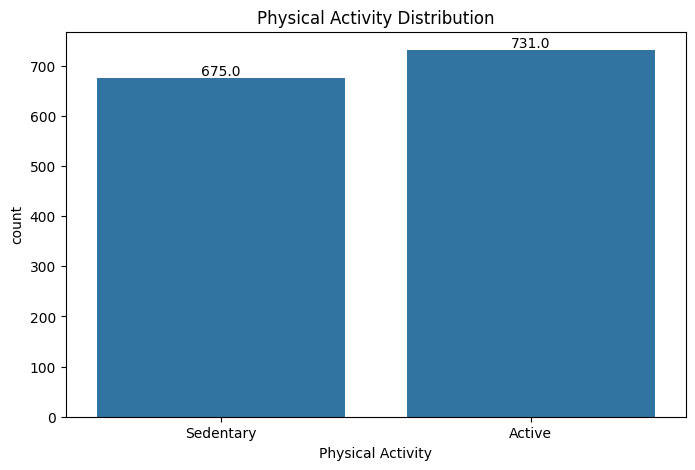


Smoking Distribution:
Smoking
Yes    714
No     692
Name: count, dtype: int64


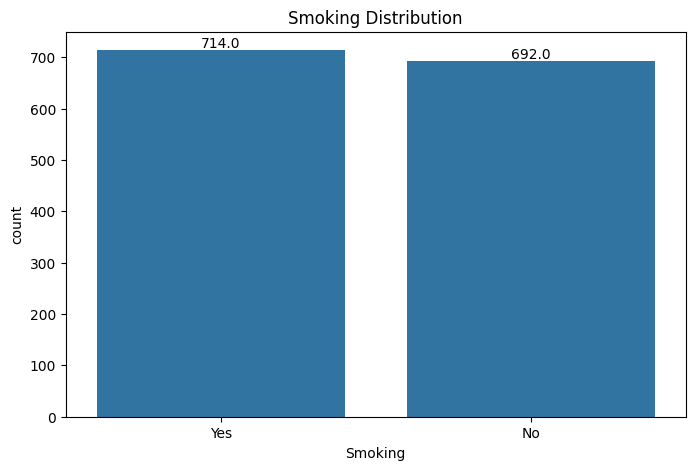


Alcohol Consumption Distribution:
Alcohol Consumption
Moderate    705
None        701
Name: count, dtype: int64


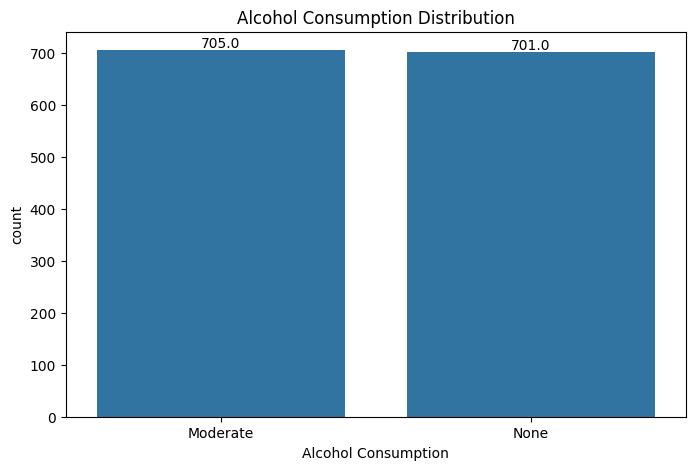


Medications Distribution:
Medications
None               717
Corticosteroids    689
Name: count, dtype: int64


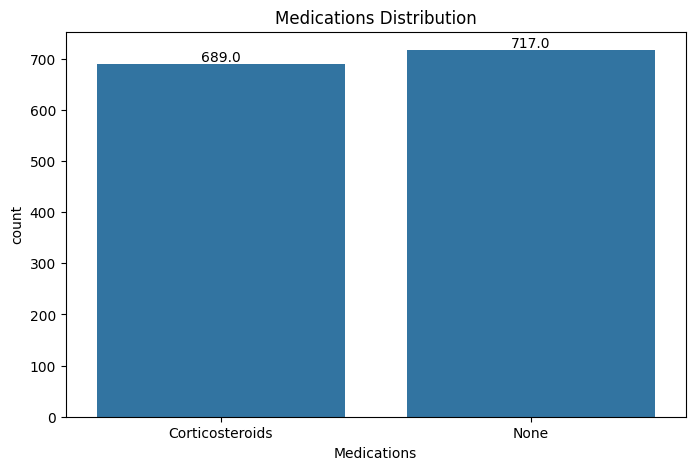


Prior Fractures Distribution:
Prior Fractures
Yes    704
No     702
Name: count, dtype: int64


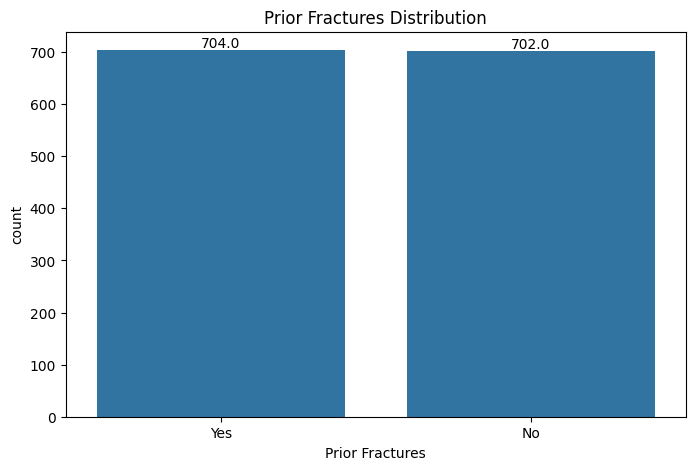


Osteoporosis Target Variable Distribution:
Osteoporosis
1    0.619488
0    0.380512
Name: proportion, dtype: float64


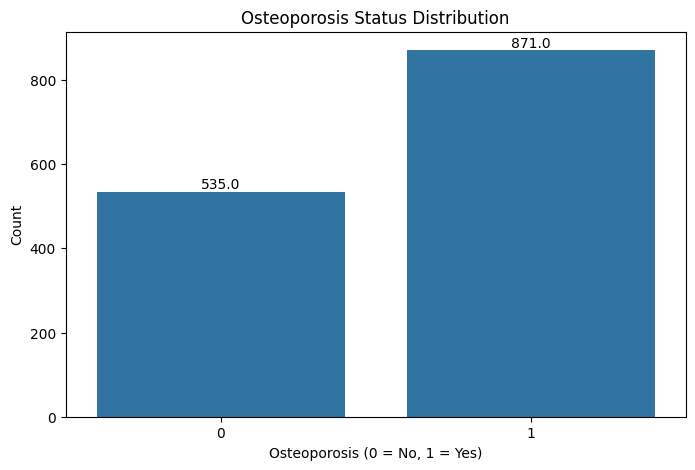

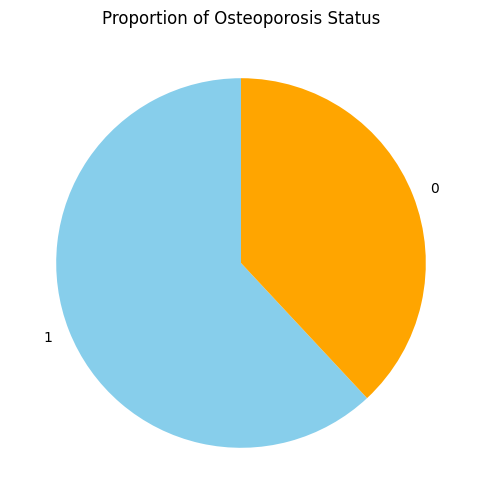


Race/Ethnicity Distribution:
Race/Ethnicity
African American    486
Caucasian           471
Asian               449
Name: count, dtype: int64


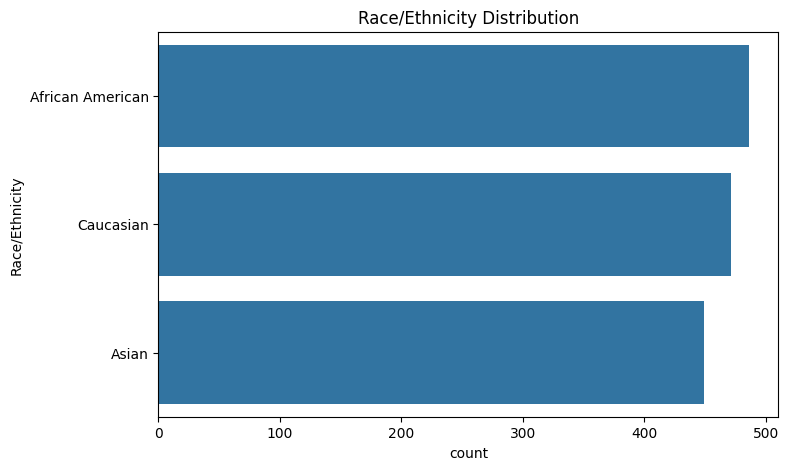


Medical Conditions Distribution:
Medical Conditions
Hyperthyroidism         493
Rheumatoid Arthritis    461
None                    452
Name: count, dtype: int64


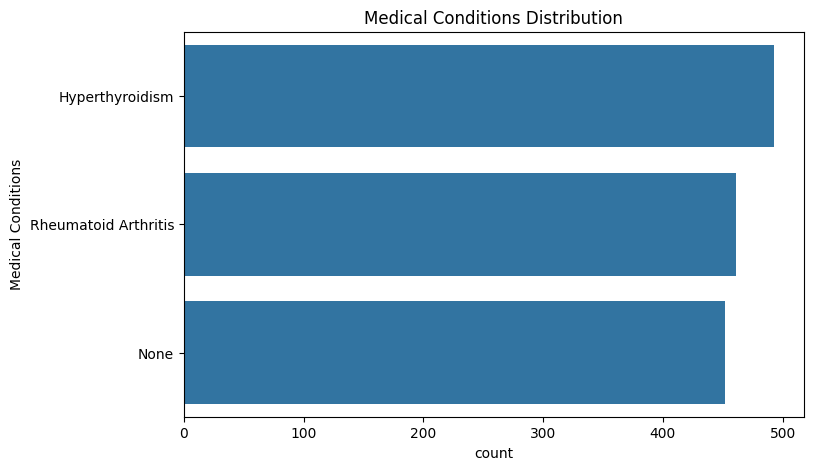

In [21]:
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black')

#------------------------------------------------------------------------------------------------------------------------

# Binary Variables Analysis
binary_vars = ['Gender', 'Hormonal Changes', 'Family History', 'Body Weight',
               'Calcium Intake', 'Vitamin D Intake', 'Physical Activity',
               'Smoking', 'Alcohol Consumption', 'Medications', 'Prior Fractures']

# Bar chart for Target Variable
for var in binary_vars:
    print(f'\n{var} Distribution:\n{df_cleaned[var].value_counts()}')
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(x=df_cleaned[var])
    add_labels(ax)
    plt.title(f'{var} Distribution')
    plt.show()

#------------------------------------------------------------------------------------------------------------------------

# Target Variable (Osteoporosis)
print("\nOsteoporosis Target Variable Distribution:")
print(df_cleaned['Osteoporosis'].value_counts(normalize=True))

# Bar chart for Target Variable
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=df_cleaned['Osteoporosis'])
add_labels(ax)  # Add frequency numbers
plt.title('Osteoporosis Status Distribution')
plt.xlabel('Osteoporosis (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Pie chart for Target Variable
plt.figure(figsize=(6, 6))
df_cleaned['Osteoporosis'].value_counts().plot.pie(colors=['skyblue', 'orange'],startangle=90)
plt.title('Proportion of Osteoporosis Status')
plt.ylabel('')
plt.show()

#------------------------------------------------------------------------------------------------------------------------

# Nominal Variables
nominal_vars = ['Race/Ethnicity', 'Medical Conditions']

# Bar chart for Nominal Variables
for var in nominal_vars:
    print(f'\n{var} Distribution:\n{df_cleaned[var].value_counts()}')
    plt.figure(figsize=(8, 5))
    sns.countplot(y=df_cleaned[var], order=df_cleaned[var].value_counts().index)
    plt.title(f'{var} Distribution')
    plt.show()

In [24]:
from scipy.stats import chi2_contingency
def analyze_contingency(df_cleaned, categorical_vars, target='Osteoporosis'):
    results = {}
    for var in categorical_vars:
        # Create contingency table
        contingency_table = pd.crosstab(df_cleaned[var], df_cleaned[target])

        # Perform Chi-square test
        chi2, p, _, _ = chi2_contingency(contingency_table)

        # Store results
        results[var] = {
            'Contingency Table': contingency_table,
            'Chi2': chi2,
            'P-value': p
        }

        print(f"\nVariable: {var}")
        print("Contingency Table:\n", contingency_table)
        print(f"Chi-square Statistic: {chi2:.2f}, P-value: {p:.4f}")


        if p < 0.05:
            print("=> There is a significant association between this variable and osteoporosis.")
            print("__________________________________________________________________________________________")
        else:
            print("=> There is no significant association between this variable and osteoporosis.")
            print("__________________________________________________________________________________________")

    return results

#------------------------------------------------------------------------------------------------------------------------

# List of independent categorical variables
categorical_vars = [
    'Gender', 'Hormonal Changes', 'Family History', 'Calcium Intake',
    'Vitamin D Intake', 'Physical Activity', 'Smoking',
    'Alcohol Consumption', 'Medications', 'Body Weight', 'Prior Fractures','Race/Ethnicity', 'Medical Conditions'
]

# contingency table
contingencyResults = analyze_contingency(df_cleaned, categorical_vars)


Variable: Gender
Contingency Table:
 Osteoporosis    0    1
Gender                
Female        275  441
Male          260  430
Chi-square Statistic: 0.05, P-value: 0.8215
=> There is no significant association between this variable and osteoporosis.
__________________________________________________________________________________________

Variable: Hormonal Changes
Contingency Table:
 Osteoporosis        0    1
Hormonal Changes          
Normal            498  483
Postmenopausal     37  388
Chi-square Statistic: 220.75, P-value: 0.0000
=> There is a significant association between this variable and osteoporosis.
__________________________________________________________________________________________

Variable: Family History
Contingency Table:
 Osteoporosis      0    1
Family History          
No              270  455
Yes             265  416
Chi-square Statistic: 0.35, P-value: 0.5549
=> There is no significant association between this variable and osteoporosis.
________________


Gender Distribution by Osteoporosis Status:
Osteoporosis    0    1
Gender                
Female        275  441
Male          260  430


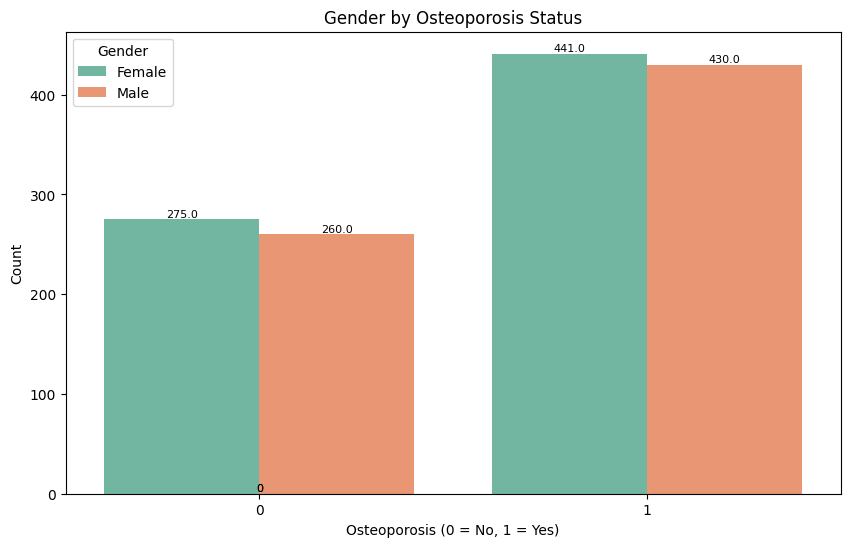


Hormonal Changes Distribution by Osteoporosis Status:
Osteoporosis        0    1
Hormonal Changes          
Normal            498  483
Postmenopausal     37  388


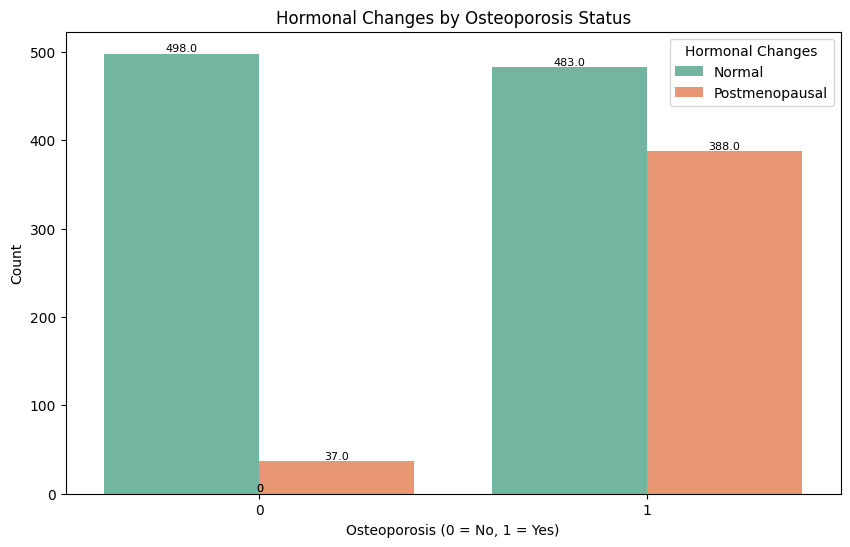


Family History Distribution by Osteoporosis Status:
Osteoporosis      0    1
Family History          
No              270  455
Yes             265  416


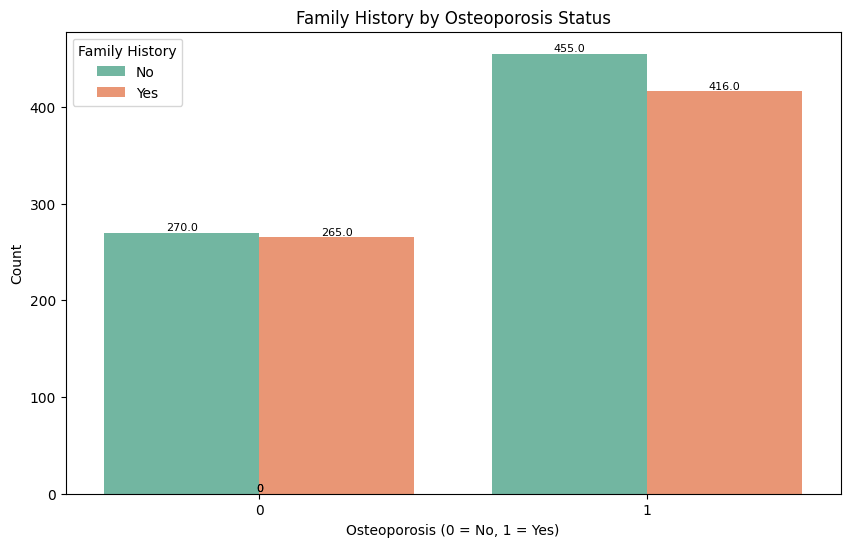


Body Weight Distribution by Osteoporosis Status:
Osteoporosis    0    1
Body Weight           
Normal        289  441
Underweight   246  430


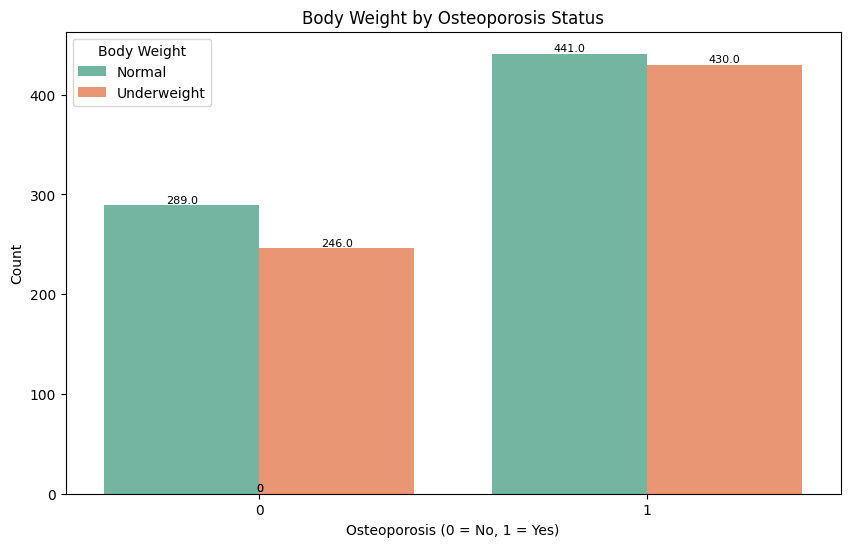


Calcium Intake Distribution by Osteoporosis Status:
Osteoporosis      0    1
Calcium Intake          
Adequate        257  422
Low             278  449


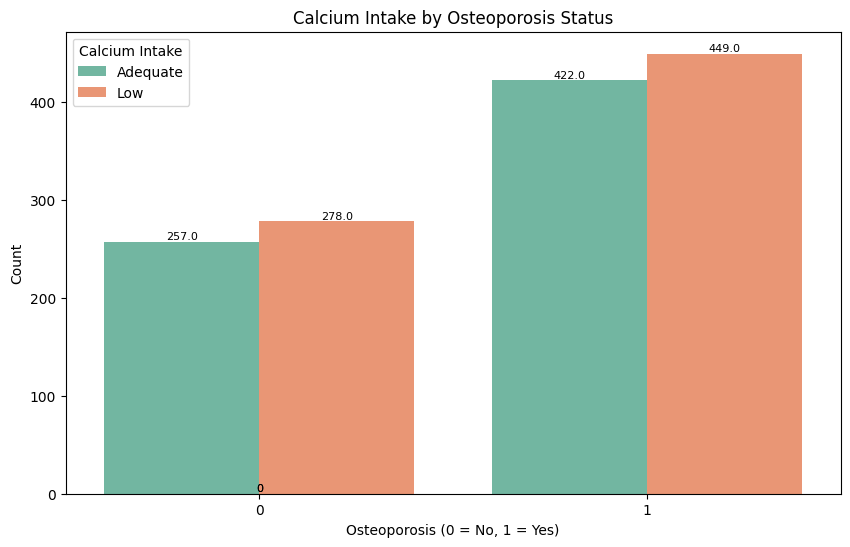


Vitamin D Intake Distribution by Osteoporosis Status:
Osteoporosis        0    1
Vitamin D Intake          
Insufficient      262  411
Sufficient        273  460


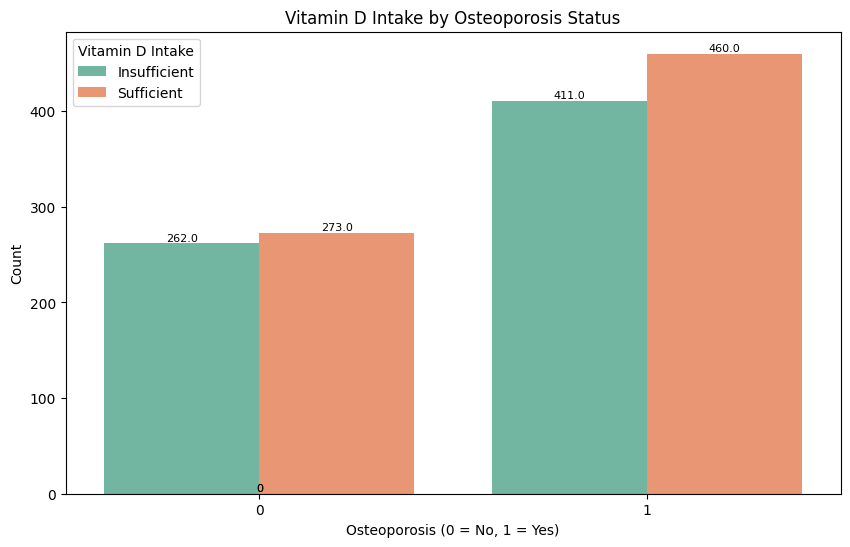


Physical Activity Distribution by Osteoporosis Status:
Osteoporosis         0    1
Physical Activity          
Active             287  444
Sedentary          248  427


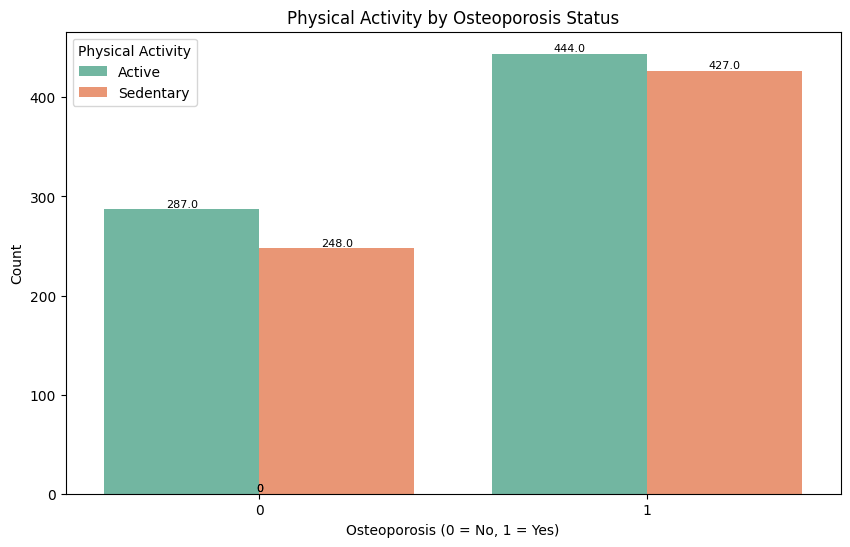


Smoking Distribution by Osteoporosis Status:
Osteoporosis    0    1
Smoking               
No            253  439
Yes           282  432


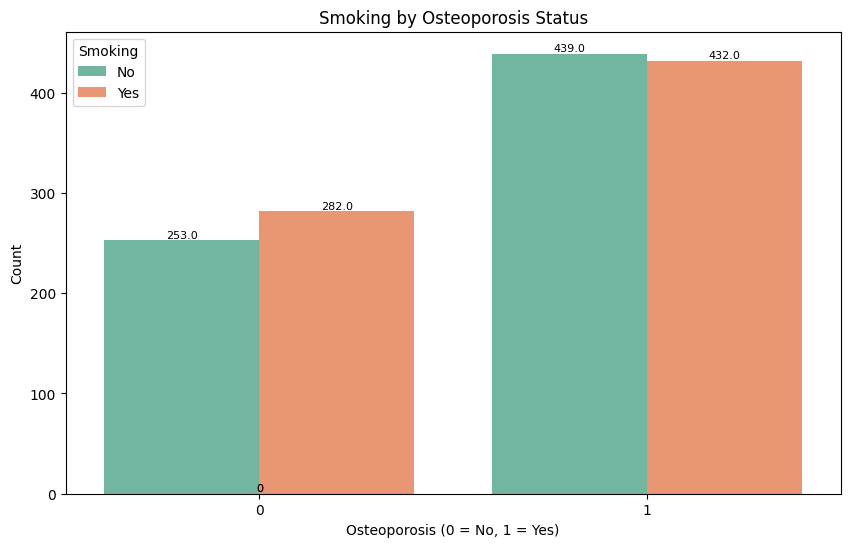


Alcohol Consumption Distribution by Osteoporosis Status:
Osteoporosis           0    1
Alcohol Consumption          
Moderate             269  436
None                 266  435


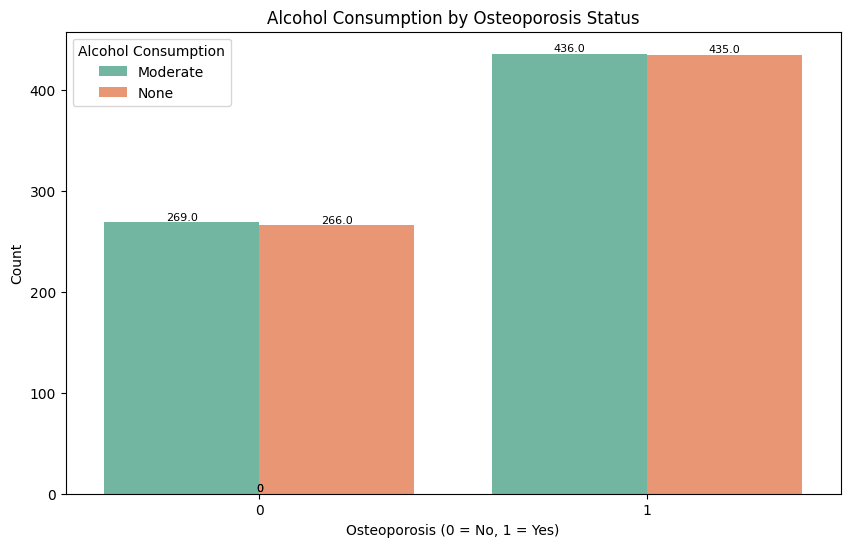


Medications Distribution by Osteoporosis Status:
Osteoporosis       0    1
Medications              
Corticosteroids  245  444
None             290  427


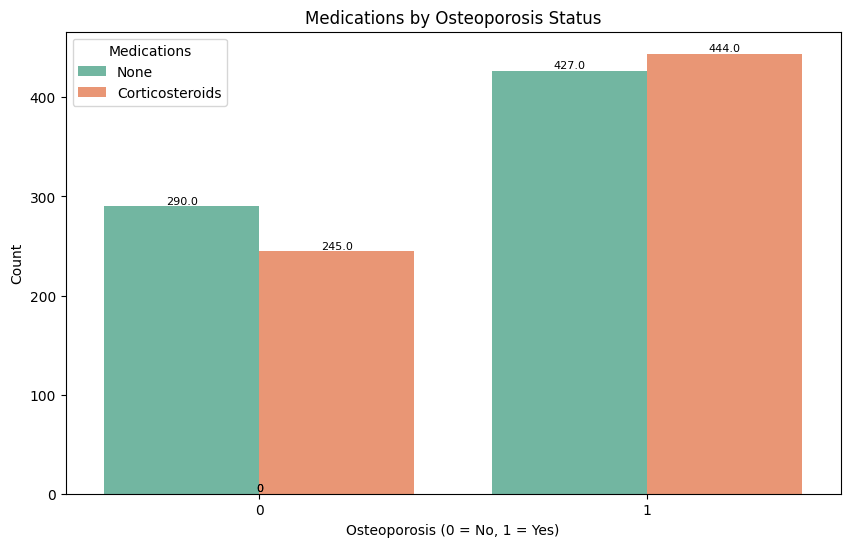


Prior Fractures Distribution by Osteoporosis Status:
Osteoporosis       0    1
Prior Fractures          
No               267  435
Yes              268  436


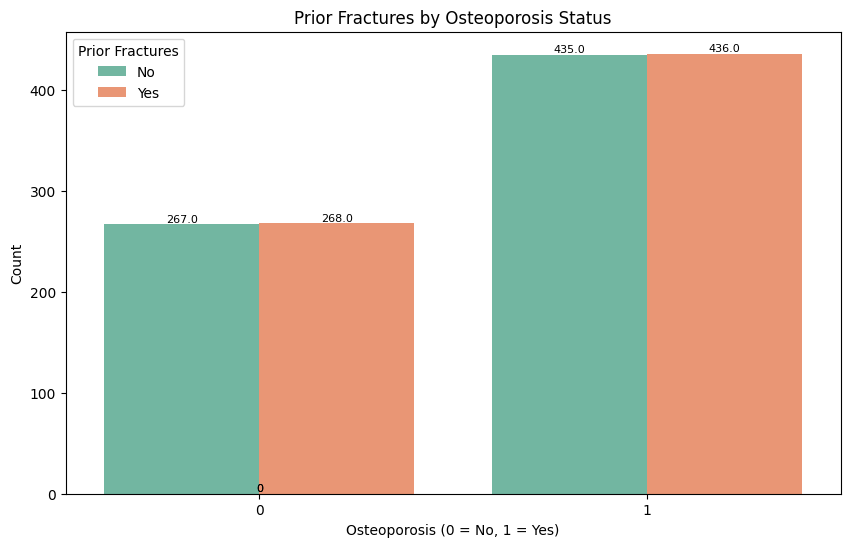


Race/Ethnicity Distribution by Osteoporosis Status:
Osteoporosis        0    1
Race/Ethnicity            
African American  179  307
Asian             172  277
Caucasian         184  287


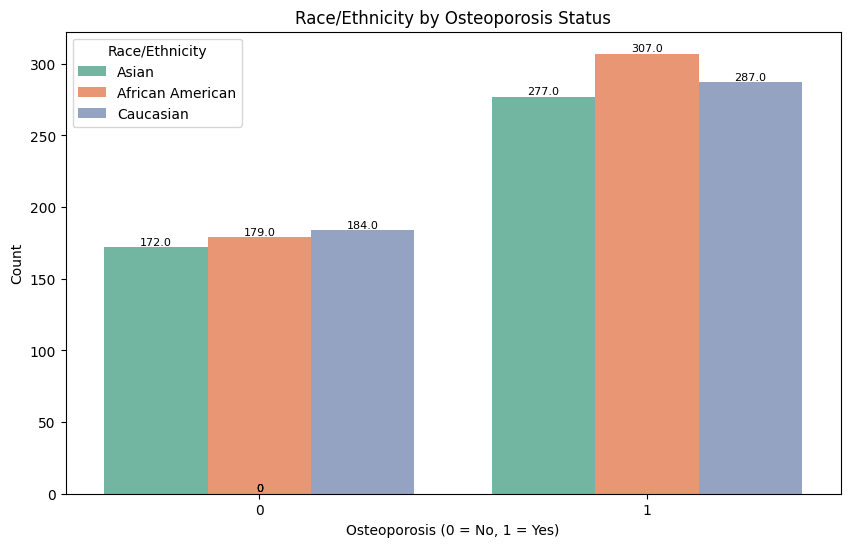


Medical Conditions Distribution by Osteoporosis Status:
Osteoporosis            0    1
Medical Conditions            
Hyperthyroidism       183  310
None                  174  278
Rheumatoid Arthritis  178  283


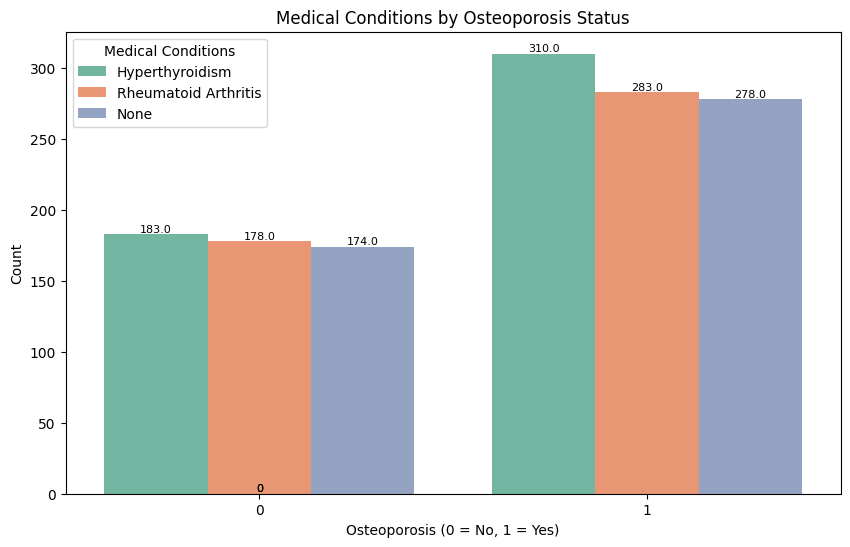

In [23]:
# Function to add labels on bars
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8, color='black')

#------------------------------------------------------------------------------------------------------------------------

# List of variables for analysis
variables = binary_vars + nominal_vars  # Combine binary and nominal variables

# Plot bar charts for each variable, conditioned on Osteoporosis status
for var in variables:
    print(f'\n{var} Distribution by Osteoporosis Status:')
    print(df_cleaned.groupby([var, 'Osteoporosis']).size().unstack(fill_value=0))

    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x='Osteoporosis', hue=var, data=df_cleaned, palette='Set2')
    add_labels(ax)
    plt.title(f'{var} by Osteoporosis Status')
    plt.xlabel('Osteoporosis (0 = No, 1 = Yes)')
    plt.ylabel('Count')
    plt.legend(title=var)
    plt.show()


<ipython-input-40-82c1941dbe9e>:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Age: 0.696
Hormonal Changes: 0.396
Medications: 0.049
Body Weight: 0.031
Smoking: 0.029
Physical Activity: 0.024
Race/Ethnicity: 0.019
Vitamin D Intake: 0.016
Family History: 0.016
Medical Conditions: 0.014
Gender: 0.006
Calcium Intake: 0.003
Alcohol Consumption: 0.001
Prior Fractures: 0.000


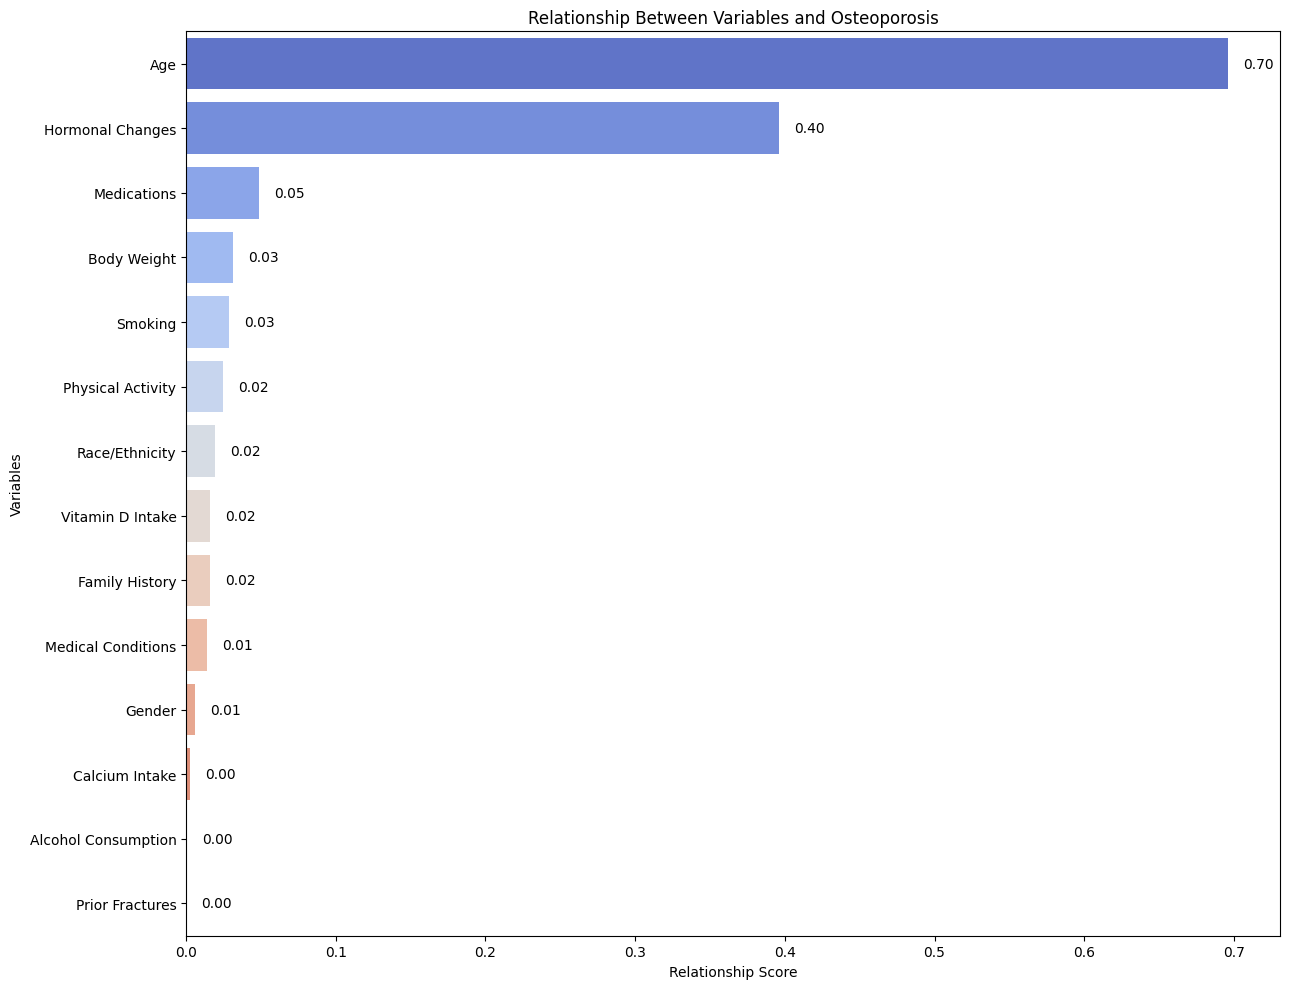

In [40]:
from scipy.stats import chi2_contingency, pointbiserialr

# Define variables
target_var = 'Osteoporosis'  # Binary target variable
categorical_vars = [
    'Gender', 'Hormonal Changes', 'Family History', 'Calcium Intake',
    'Vitamin D Intake', 'Physical Activity', 'Smoking',
    'Alcohol Consumption', 'Medications', 'Body Weight', 'Prior Fractures',
    'Race/Ethnicity', 'Medical Conditions'
]
numerical_vars = ['Age']

#------------------------------------------------------------------------------------------------------------------------

# Function to calculate Cramér's V
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    return np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

#------------------------------------------------------------------------------------------------------------------------

# Function to calculate Point-Biserial Correlation
def point_biserial_correlation(binary_var, continuous_var):
    return pointbiserialr(binary_var, continuous_var)[0]

#------------------------------------------------------------------------------------------------------------------------

# Initialize a results dictionary
relations = {}

# Calculate relationships for categorical variables
for cat_var in categorical_vars:
    relations[cat_var] = cramers_v(df_cleaned[cat_var], df_cleaned[target_var])

# Calculate relationships for numerical variables
for num_var in numerical_vars:
    relations[num_var] = point_biserial_correlation(df_cleaned[target_var], df_cleaned[num_var])

# Convert results into a DataFrame
relations_df_cleaned = pd.DataFrame.from_dict(relations, orient='index', columns=['Relationship Score'])

# Sort by relationship strength
relations_df_cleaned = relations_df_cleaned.sort_values(by='Relationship Score', ascending=False)

#------------------------------------------------------------------------------------------------------------------------

# Plot results
plt.figure(figsize=(13,10))
ax = sns.barplot(
    x=relations_df_cleaned['Relationship Score'],
    y=relations_df_cleaned.index,
    palette='coolwarm'
)
#------------------------------------------------------------------------------------------------------------------------

# Add score annotations on the bars
for i, score in enumerate(relations_df_cleaned['Relationship Score']):
    ax.text(score + 0.01, i, f'{score:.2f}', color='black', va='center')
    print(f'{relations_df_cleaned.index[i]}: {score:.3f}')

plt.title('Relationship Between Variables and Osteoporosis')
plt.xlabel('Relationship Score')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()


<ipython-input-41-70ed319dbd87>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_means = values.groupby(categories).mean()
<ipython-input-41-70ed319dbd87>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  between_group_variance = np.sum(values.groupby(categories).size() * (category_means - overall_mean)**2)
<ipython-input-41-70ed319dbd87>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_means = values

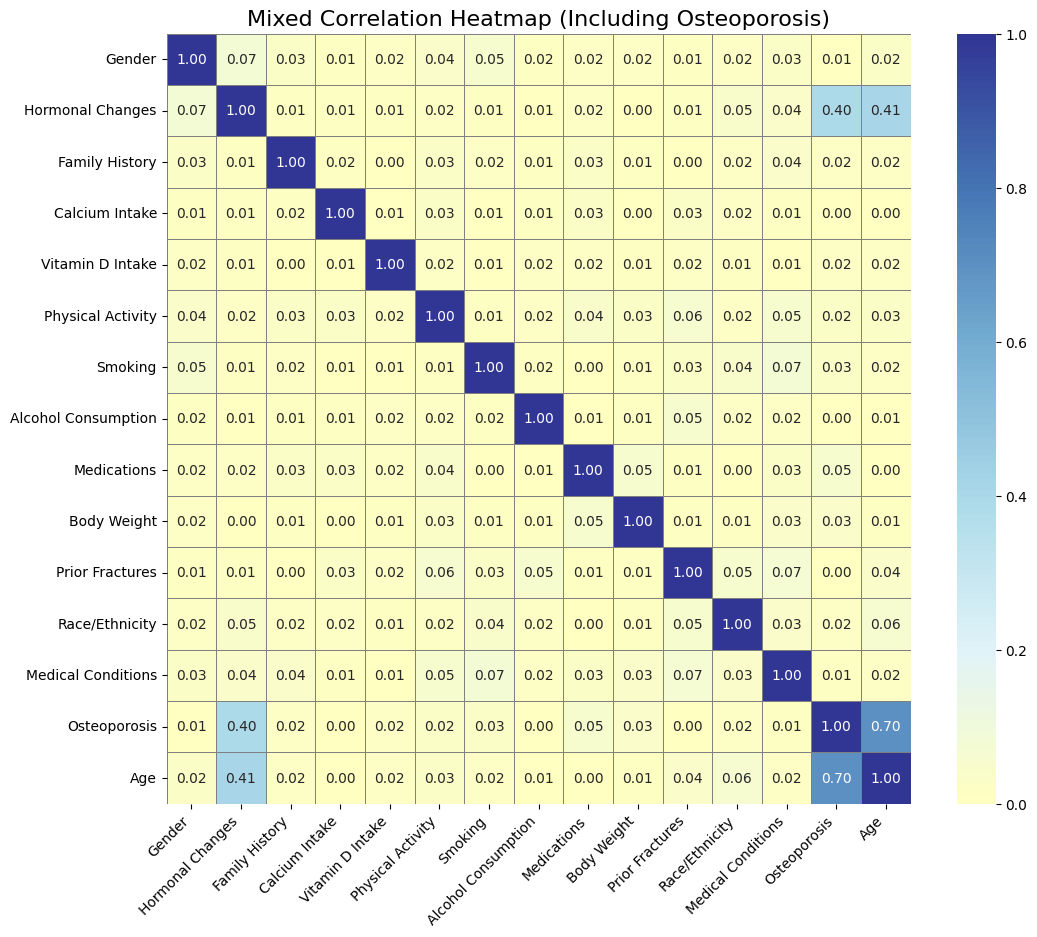

In [41]:

categorical_vars = [
    'Gender', 'Hormonal Changes', 'Family History', 'Calcium Intake',
    'Vitamin D Intake', 'Physical Activity', 'Smoking',
    'Alcohol Consumption', 'Medications', 'Body Weight', 'Prior Fractures',
    'Race/Ethnicity', 'Medical Conditions', 'Osteoporosis'
]
numerical_vars = ['Age']

# Function to calculate Cramér's V
def cramers_v(x, y):
    """
    Calculates Cramér's V for categorical vs categorical data.
    """
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    return np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

#------------------------------------------------------------------------------------------------------------------------

# Function to calculate Correlation Ratio (η)
def correlation_ratio(categories, values):
    """
    Calculates the Correlation Ratio (η) for categorical vs numerical data.
    """
    categories = categories.astype('category')
    category_means = values.groupby(categories).mean()
    overall_mean = values.mean()
    between_group_variance = np.sum(values.groupby(categories).size() * (category_means - overall_mean)**2)
    total_variance = np.sum((values - overall_mean)**2)
    return np.sqrt(between_group_variance / total_variance)

#------------------------------------------------------------------------------------------------------------------------

# Initialize an empty matrix
all_vars = categorical_vars + numerical_vars
correlation_matrix = pd.DataFrame(index=all_vars, columns=all_vars)

# Populate the matrix
for var1 in all_vars:
    for var2 in all_vars:
        if var1 in categorical_vars and var2 in categorical_vars:
            # Categorical vs Categorical (Cramér's V)
            correlation_matrix.loc[var1, var2] = cramers_v(df_cleaned[var1], df_cleaned[var2])
        elif var1 in categorical_vars and var2 in numerical_vars:
            # Categorical vs Numerical (Correlation Ratio)
            correlation_matrix.loc[var1, var2] = correlation_ratio(df_cleaned[var1], df_cleaned[var2])
        elif var1 in numerical_vars and var2 in categorical_vars:
            # Numerical vs Categorical (Correlation Ratio)
            correlation_matrix.loc[var1, var2] = correlation_ratio(df_cleaned[var2], df_cleaned[var1])
        elif var1 in numerical_vars and var2 in numerical_vars:
            # Numerical vs Numerical (Pearson Correlation)
            correlation_matrix.loc[var1, var2] = df_cleaned[[var1, var2]].corr().iloc[0, 1]

#------------------------------------------------------------------------------------------------------------------------

# Convert matrix values to floats for heatmap compatibility
correlation_matrix = correlation_matrix.astype(float)

# Plot the heatmap with a new color palette
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdYlBu",  # Diverging palette: Red to Yellow to Blue
    cbar=True,
    fmt=".2f",
    linewidths=0.5,  # Add cell dividers
    linecolor='gray',  # Divider color
    center=0  # Center the color range at 0
)
plt.title('Mixed Correlation Heatmap (Including Osteoporosis)', fontsize=16)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.show()

In [44]:
# Format the correlation matrix with two decimal places (matching the heatmap display)
formatted_matrix = correlation_matrix.applymap(lambda x: f"{x:.2f}")

# Print the formatted matrix as a table
print("Heatmap Values (Formatted):")
print(formatted_matrix.to_string(index=True))


Heatmap Values (Formatted):
                    Gender Hormonal Changes Family History Calcium Intake Vitamin D Intake Physical Activity Smoking Alcohol Consumption Medications Body Weight Prior Fractures Race/Ethnicity Medical Conditions Osteoporosis   Age
Gender                1.00             0.07           0.03           0.01             0.02              0.04    0.05                0.02        0.02        0.02            0.01           0.02               0.03         0.01  0.02
Hormonal Changes      0.07             1.00           0.01           0.01             0.01              0.02    0.01                0.01        0.02        0.00            0.01           0.05               0.04         0.40  0.41
Family History        0.03             0.01           1.00           0.02             0.00              0.03    0.02                0.01        0.03        0.01            0.00           0.02               0.04         0.02  0.02
Calcium Intake        0.01             0.01         

<ipython-input-44-440ad1c2cf82>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_matrix = correlation_matrix.applymap(lambda x: f"{x:.2f}")


The dataset is very balanced with regard to the osteoporosis variable.

## Relation between osteoporosis and medication

Calcium Intake vs Osteoporosis:

Osteoporosis      0    1
Calcium Intake          
Adequate        257  422
Low             278  449

Vitamin D Intake vs Osteoporosis:

Osteoporosis        0    1
Vitamin D Intake          
Insufficient      262  411
Sufficient        273  460

Corticosteroids Usage vs Osteoporosis:

Osteoporosis       0    1
Medications              
Corticosteroids  245  444
None             290  427


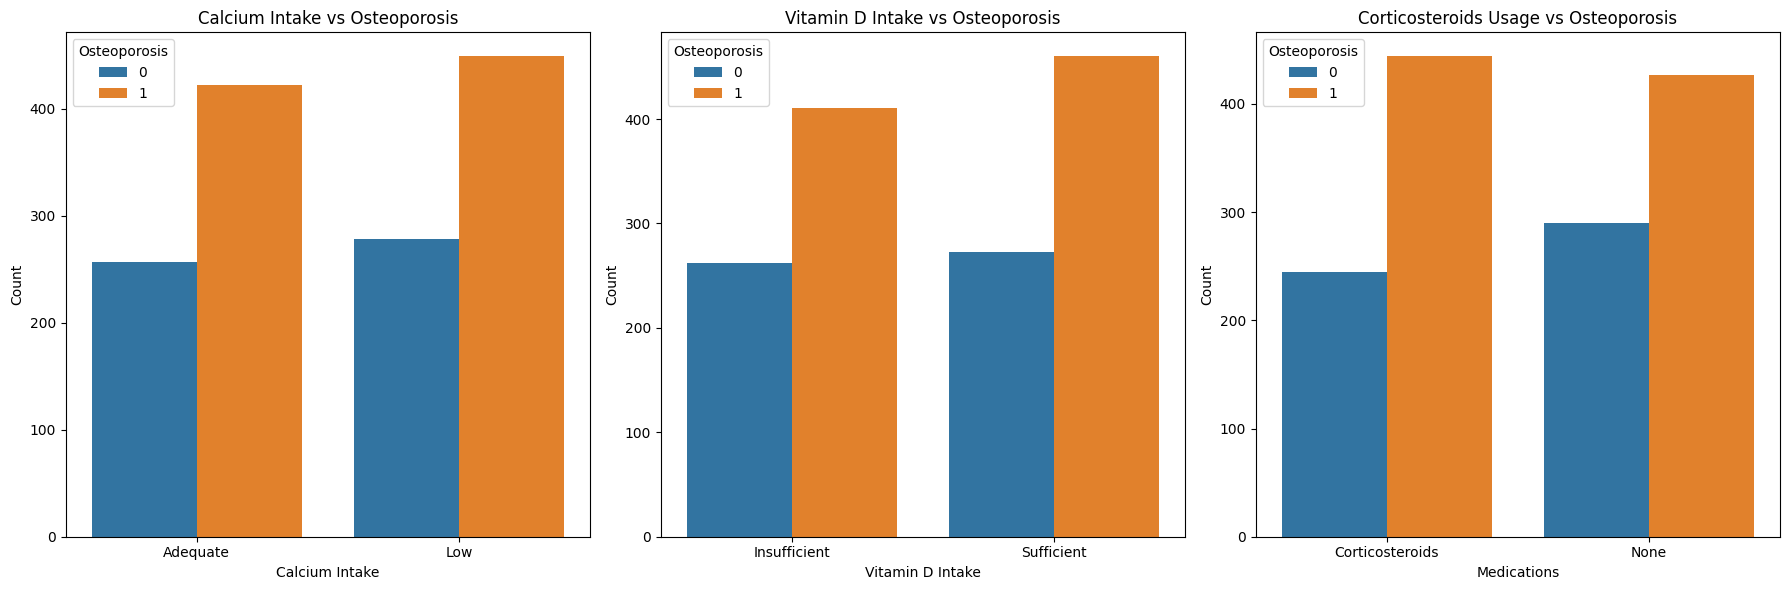

In [ ]:
# Checking the relationship between Calcium Intake and Osteoporosis
calcium_vs_osteoporosis = pd.crosstab(df_cleaned['Calcium Intake'], df_cleaned['Osteoporosis'])
print("Calcium Intake vs Osteoporosis:\n")
print(calcium_vs_osteoporosis)

# Checking the relationship between Vitamin D Intake and Osteoporosis
vitamin_d_vs_osteoporosis = pd.crosstab(df_cleaned['Vitamin D Intake'], df_cleaned['Osteoporosis'])
print("\nVitamin D Intake vs Osteoporosis:\n")
print(vitamin_d_vs_osteoporosis)

# Checking the relationship between Medications (Corticosteroids) and Osteoporosis
if 'Medications' in df_cleaned.columns:
    medications_vs_osteoporosis = pd.crosstab(df_cleaned['Medications'], df_cleaned['Osteoporosis'])
    print("\nCorticosteroids Usage vs Osteoporosis:\n")
    print(medications_vs_osteoporosis)
else:
    print("\nMedications column is missing or not properly defined in the dataset.")

# Visualizing the results with graphs
plt.figure(figsize=(18, 6))

# Graph for Calcium Intake
plt.subplot(1, 3, 1)
sns.barplot(data=calcium_vs_osteoporosis.reset_index().melt(id_vars='Calcium Intake'),
            x='Calcium Intake', y='value', hue='Osteoporosis')
plt.title('Calcium Intake vs Osteoporosis')
plt.ylabel('Count')
plt.xlabel('Calcium Intake')

# Graph for Vitamin D Intake
plt.subplot(1, 3, 2)
sns.barplot(data=vitamin_d_vs_osteoporosis.reset_index().melt(id_vars='Vitamin D Intake'),
            x='Vitamin D Intake', y='value', hue='Osteoporosis')
plt.title('Vitamin D Intake vs Osteoporosis')
plt.ylabel('Count')
plt.xlabel('Vitamin D Intake')

# Graph for Medications (Corticosteroids):
if 'Medications' in df_cleaned.columns:
    plt.subplot(1, 3, 3)
    sns.barplot(data=medications_vs_osteoporosis.reset_index().melt(id_vars='Medications'),
                x='Medications', y='value', hue='Osteoporosis')
    plt.title('Corticosteroids Usage vs Osteoporosis')
    plt.ylabel('Count')
    plt.xlabel('Medications')

plt.tight_layout()
plt.show()


# Model

### Introduction to Modeling

In machine learning, a **model** is a mathematical representation that captures the relationships between the input features (predictors) and the target variable (outcome). The primary objective of a model is to make accurate predictions on unseen data by learning patterns from the training dataset. This process involves identifying a function \( f(X) \) that maps the input features \( X \) to the target \( y \), where \( X \) represents the predictor variables and \( y \) is the outcome of interest.

The modeling process typically consists of the following steps:
1. **Model Selection**: Choosing the appropriate model(s) based on the nature of the data and the problem (e.g., classification, regression).
2. **Training**: Using a subset of the data (training set) to optimize the parameters of the model by minimizing a predefined loss function.
3. **Validation**: Evaluating the model's performance on unseen data (validation set) to tune hyperparameters and prevent overfitting.
4. **Testing**: Assessing the final performance on a separate test dataset to measure generalization.

For this project, focused on predicting osteoporosis, we explored **supervised learning models**, where the outcome variable (presence or absence of osteoporosis) is known and serves as the basis for training. We selected the following models for their complementary strengths and relevance to the classification task:
1. **Logistic Regression**: A statistical method that models the relationship between the features and the log-odds of the binary outcome. It is a widely used linear model due to its simplicity, interpretability, and efficiency.
2. **Decision Tree Classifier**: A tree-based model that splits the data into subsets based on feature thresholds, constructing a hierarchy of decisions to classify instances. Decision trees are interpretable and handle non-linear relationships effectively.


Each of these models represents a different approach to solving the classification problem:
- **Logistic Regression** assumes a linear relationship and is well-suited for datasets where such assumptions hold.
- **Decision Trees** is highly interpretable, making them ideal for understanding the relative importance of features.

The hyperparameters of these models were tuned using **Grid Search** and evaluated using **Cross-Validation** to ensure robust performance. Metrics such as **accuracy**, **precision**, **recall**, and **F1-score** were employed to compare the models, complemented by confusion matrices to gain insight into the nature of classification errors.

The models were specifically chosen for this project to address the challenges of classifying osteoporosis, a medical condition influenced by multiple interacting factors. By comparing these approaches, we aim to identify the model that balances interpretability and predictive power, providing meaningful insights into the risk factors for osteoporosis and enabling accurate predictions for future patients.

In the following sections, we delve deeper into the theoretical foundations and practical applications of each model, explaining how they were implemented, tuned, and evaluated in this project.


In [ ]:
x=df_encoded.drop('Osteoporosis',axis=1)
y=df_encoded['Osteoporosis']

In [ ]:
# Split the data into train and test sets
x_train_fold, x_test_fold, y_train_fold, y_test_fold = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

## Model 1 : Logistic Regression


Logistic Regression, or Logit Model, is one of the best statistical tools for analyzing and modeling events that can be described with a binary categorical variable. Beside the possibility of a prediction, the Logit Model is also very useful to visualize the wheights of the different indipendent variable on the possible prediction.

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

For the Logistic Regression we used the one from statsmodel since it gives an R-like results which gives a lot more information about the variables and the model itself.
The data was already encoded and divided in train and test, so we just have to fit the model now and add a constant.

In [ ]:
# Add a constant (intercept) to X

x_logit = x_train_fold.copy()
x_logit['const'] = 1




# create logit model
logit_model = sm.Logit(y_train_fold, x_logit)

# adapt the model
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.304101
         Iterations 8


In [ ]:
# Print model summary
print(result.summary())


                           Logit Regression Results                           
Dep. Variable:           Osteoporosis   No. Observations:                 1124
Model:                          Logit   Df Residuals:                     1109
Method:                           MLE   Df Model:                           14
Date:                Sun, 19 Jan 2025   Pseudo R-squ.:                  0.5423
Time:                        18:02:01   Log-Likelihood:                -341.81
converged:                       True   LL-Null:                       -746.84
Covariance Type:            nonrobust   LLR p-value:                7.814e-164
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Age                     0.1618      0.012     13.917      0.000       0.139       0.185
Gender                  0.0419      0.204      0.205      0.838      -0.358       0.442
Hormonal Changes

Looking at the results above there's much to discuss.
The P-values quantifies how relevant the variables are for the prediction, showing the Age is the most important, followed by Medications, Hormonal Changes, Smoking and Prior Fractures.
The "coef" is the wheight β of the variables in the regression equation. A positive coef means that the associated variable increase the probability of Y while a negative one decreases it.
It does not come as a surprise that "Medications" and "Calcium Intake" have a negative coefficients, but it is weird to see that "Smoking" has too. As for the positive coefficients the ones that have more importance are Prior Fractures, Hormonal Changes and Vitamin D intake.

To understand how good the model is it's useful to analyze the "Pseudo R-squ", the "Log-Likehood" and the "LLR p-value".
The "Log-Likehood" shows how good the model fits to the data, the higher it is in respect to the "Log-Likehood Null", better is the model. Here there is a great difference between the two of them, so the this model is doing a much better job than the null model.
The Pseudo R-square is bigger than 0.5, it means that there may be an overfitting problem.



Since "Age" is the most relevant variable but also the only non binary it could be interesting to observe a model without it and see if some variable become more relevant.

In [ ]:
# Create a new copy of data set
x_logit2 = x_train_fold.copy()

# List of variables that we want to remove
variabili_to_remove = ['Age']

# Removing the variables
x_logit2 = x_logit2.drop(columns=variabili_to_remove)

# Check results
print("Originals variables:", x_logit.columns)
print("Variabili dopo la rimozione:", x_logit2.columns)

Originals variables: Index(['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
       'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'const'],
      dtype='object')
Variabili dopo la rimozione: Index(['Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
       'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures'],
      dtype='object')


In [ ]:
x_logit2 = sm.add_constant(x_logit2)

logit_model2 = sm.Logit(y_train_fold, x_logit2)


result2 = logit_model2.fit()

print(result2.summary())

Optimization terminated successfully.
         Current function value: 0.576510
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           Osteoporosis   No. Observations:                 1124
Model:                          Logit   Df Residuals:                     1110
Method:                           MLE   Df Model:                           13
Date:                Sun, 19 Jan 2025   Pseudo R-squ.:                  0.1323
Time:                        18:02:01   Log-Likelihood:                -648.00
converged:                       True   LL-Null:                       -746.84
Covariance Type:            nonrobust   LLR p-value:                 4.091e-35
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.0219      0.255     -0.086      0.932      -0.521       0.477
Ge

It's pretty clear from the "Log-Likehood" value, since it's not very different from the null one, that this model is totally useless

Now, let's try a model without some of the least relevant variables that have the p-value grater than 0.5 on the first regression.

In [ ]:
# yet another copy for last test
x_logit3 = x_train_fold.copy()

variabili_to_remove2 = ['Family History','Race/Ethnicity','Gender','Alcohol Consumption','Calcium Intake','Hormonal Changes']  # Sostituisci con le variabili che vuoi rimuovere


x_logit3 = x_logit3.drop(columns=variabili_to_remove2)


print("Variabili originali:", x_logit.columns)
print("Variabili dopo la rimozione:", x_logit3.columns)

Variabili originali: Index(['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
       'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'const'],
      dtype='object')
Variabili dopo la rimozione: Index(['Age', 'Body Weight', 'Vitamin D Intake', 'Physical Activity',
       'Smoking', 'Medical Conditions', 'Medications', 'Prior Fractures'],
      dtype='object')


In [ ]:
x_logit3 = sm.add_constant(x_logit3)

logit_model3 = sm.Logit(y_train_fold, x_logit3)


result3 = logit_model3.fit()

print(result3.summary())

Optimization terminated successfully.
         Current function value: 0.304842
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           Osteoporosis   No. Observations:                 1124
Model:                          Logit   Df Residuals:                     1115
Method:                           MLE   Df Model:                            8
Date:                Sun, 19 Jan 2025   Pseudo R-squ.:                  0.5412
Time:                        18:02:01   Log-Likelihood:                -342.64
converged:                       True   LL-Null:                       -746.84
Covariance Type:            nonrobust   LLR p-value:                3.199e-169
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -5.4546      0.447    -12.208      0.000      -6.330      -4.579
Age  

There is a very little difference between this model and the complete one, showing again how irrelevant other variables are for prediction in respect to "Age"

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


The goodness of the model can also be verified with the observation of the ROC curve, the plot of the true positive rate against the false positive rate.
Since the second model does not give any useful information and the third is just a slightly worse version of the first, let's analyze the latter.

In [ ]:
# Prediction with the first model with train dataset
y_prob2 = result.predict(x_logit)

# Derive ROC Curve
fpr2, tpr2, _ = roc_curve(y_train_fold, y_prob2)
roc_auc2 = auc(fpr2, tpr2)

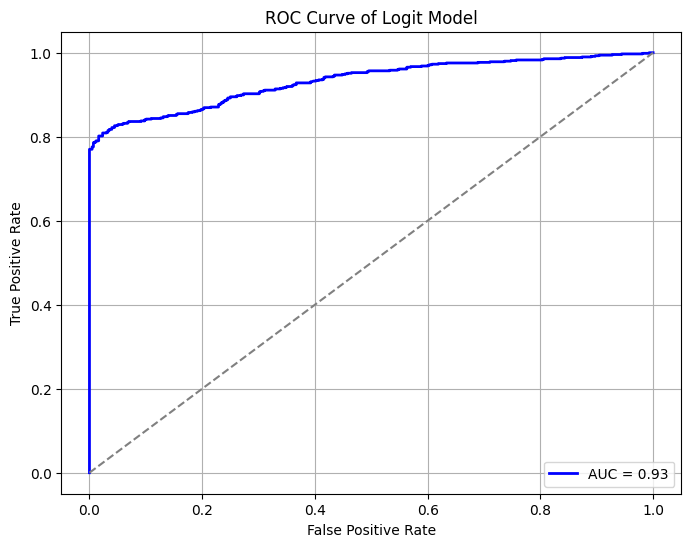

In [ ]:
# Draw ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr2, tpr2, color='blue', lw=2, label=f"AUC = {roc_auc2:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Linea casuale
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Logit Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The AUC score of 0.93 is an excellent score, showing that the model does a pretty good job


From ROC Curve alone it is impossible to quantify the exact number of good and bad prediction of the model, so it is better to also use the confusion matrix for that.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score

Confusion Matrix:
[[342  86]
 [ 93 603]]

True Positive (TP): 603
False Positive (FP): 86
True Negative (TN): 342
False Negative (FN): 93


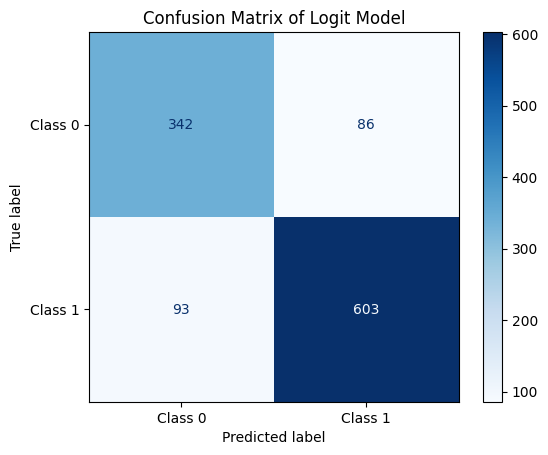

accuracy test =  0.8407473309608541
precision test =  0.8751814223512336
recall test =  0.8663793103448276
f1 test =  0.8707581227436824


In [ ]:
# Convert results in binary classes by a classification treshold
threshold = 0.5  # Standard Treshold
y_pred2 = (y_prob2 >= threshold).astype(int)  # Binary classification

# Confusion Metrix
cm = confusion_matrix(y_train_fold, y_pred2)

# Matrix component extraction
tn, fp, fn, tp = cm.ravel()  # TN, FP, FN, TP

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"True Negative (TN): {tn}")
print(f"False Negative (FN): {fn}")

# Grafic Visualization of Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix of Logit Model")
plt.show()

print("accuracy test = " , accuracy_score(y_train_fold, y_pred2))
print("precision test = " , precision_score(y_train_fold, y_pred2))
print("recall test = " , recall_score(y_train_fold, y_pred2))
print("f1 test = " , f1_score(y_train_fold, y_pred2))

These results show that the model is doing a good job on the "train" datas, so it is time to aplly it on the "test" sample.

In [ ]:
# Prediction with the first model with test dataset
x_test = x_test_fold.copy()
x_test['const'] = 1
y_prob = result.predict(x_test)

# Derive ROC Curve
fpr, tpr, _ = roc_curve(y_test_fold, y_prob)
roc_auc = auc(fpr, tpr)


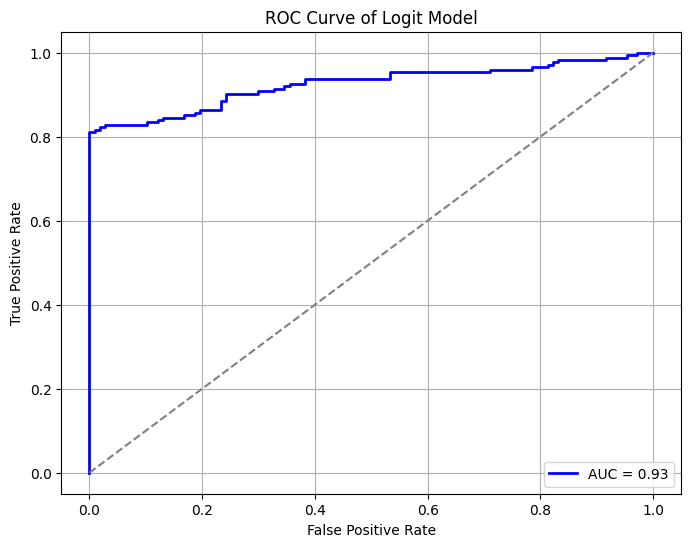

In [ ]:
# Draw ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Linea casuale
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Logit Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Confusion Matrix:
[[ 88  19]
 [ 26 149]]

True Positive (TP): 149
False Positive (FP): 19
True Negative (TN): 88
False Negative (FN): 26


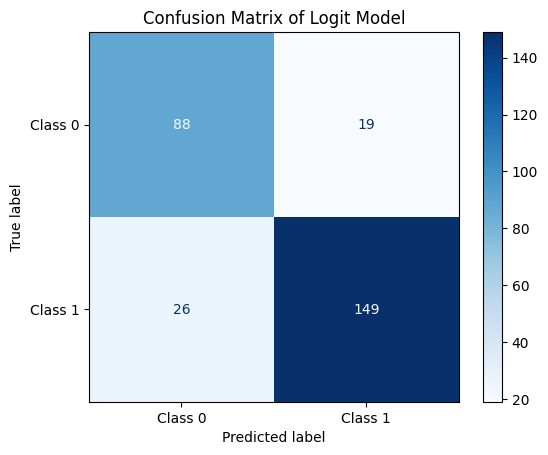

accuracy test =  0.8404255319148937
precision test =  0.8869047619047619
recall test =  0.8514285714285714
f1_score =  0.8688046647230321


In [ ]:
# Convert results in binary classes by a classification treshold
threshold = 0.5  # Standard Treshold
y_pred = (y_prob >= threshold).astype(int)  # Binary classification

# Confusion Metrix
cm = confusion_matrix(y_test_fold, y_pred)

# Matrix component extraction
tn, fp, fn, tp = cm.ravel()  # TN, FP, FN, TP

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"True Negative (TN): {tn}")
print(f"False Negative (FN): {fn}")

# Grafic Visualization of Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix of Logit Model")
plt.show()

print("accuracy test = " , accuracy_score(y_test_fold, y_pred))
print("precision test = " , precision_score(y_test_fold, y_pred))
print("recall test = " , recall_score(y_test_fold, y_pred))
print("f1_score = " , f1_score(y_test_fold, y_pred))

The results didn't change much, so the model is not too specific and is doing a pretty good job in prediction.

For the third logit model we tried manually removing some variables that were considered "useless" since, from the results of logit1, they appeared to be less correlated to the predicted variable than others, but the result was slightly worse than the complete model. Now we want to see if by introducing a penalty with LASSO and RIDGE Regression we can have even better results on our model.

For three previous models we used the Statsmodel library for getting as much information as we could, but that library is better suited for statistical analysis. Now , for RIDGE and LASSO Regression, we are gonna use the sklearn Logistic Regression since it is more suited for this kind of work.

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
#Ridge Logistic Regression on train dataset
ridge_model = LogisticRegression(penalty='l2', solver='liblinear', C=1)
ridge_model.fit(x_logit, y_train_fold)



LogisticRegression(C=1, solver='liblinear')

In [ ]:

y_prob_ridge = ridge_model.predict(x_logit)

# Derive ROC Curve
fpr3, tpr3, _ = roc_curve(y_train_fold, y_prob_ridge)
roc_auc3 = auc(fpr3, tpr3)

Confusion Matrix:
[[342  86]
 [ 92 604]]

True Positive (TP): 604
False Positive (FP): 86
True Negative (TN): 342
False Negative (FN): 92


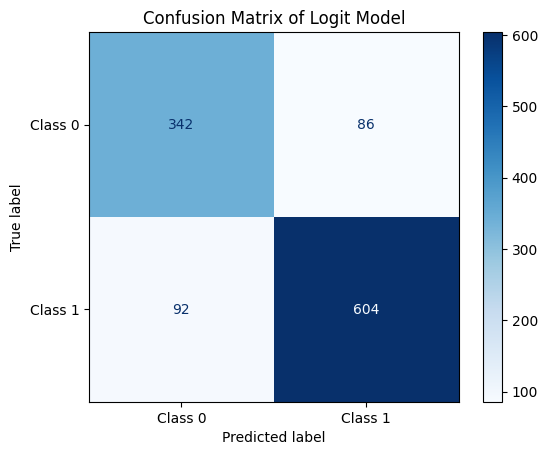

accuracy test =  0.8416370106761566
precision test =  0.8753623188405797
recall test =  0.867816091954023
f1 test =  0.8715728715728716


In [ ]:
# Convert results in binary classes by a classification treshold
threshold = 0.5  # Standard Treshold
y_pred3 = (y_prob_ridge >= threshold).astype(int)  # Binary classification

# Confusion Metrix
cm = confusion_matrix(y_train_fold, y_pred3)

# Matrix component extraction
tn, fp, fn, tp = cm.ravel()  # TN, FP, FN, TP

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"True Negative (TN): {tn}")
print(f"False Negative (FN): {fn}")

# Grafic Visualization of Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix of Logit Model")
plt.show()

print("accuracy test = " , accuracy_score(y_train_fold, y_pred3))
print("precision test = " , precision_score(y_train_fold, y_pred3))
print("recall test = " , recall_score(y_train_fold, y_pred3))
print("f1 test = " , f1_score(y_train_fold, y_pred3))

The confusion matrix shows that when working on the train data the RIDGE Logit model is almost identical to the first Logit model with a small improvement (one more true positive correctly classified).

In [ ]:

y_prob_ridge = ridge_model.predict(x_test)

# Derive ROC Curve
fpr3, tpr3, _ = roc_curve(y_test_fold, y_prob_ridge)
roc_auc3 = auc(fpr3, tpr3)

Confusion Matrix:
[[ 88  19]
 [ 26 149]]

True Positive (TP): 149
False Positive (FP): 19
True Negative (TN): 88
False Negative (FN): 26


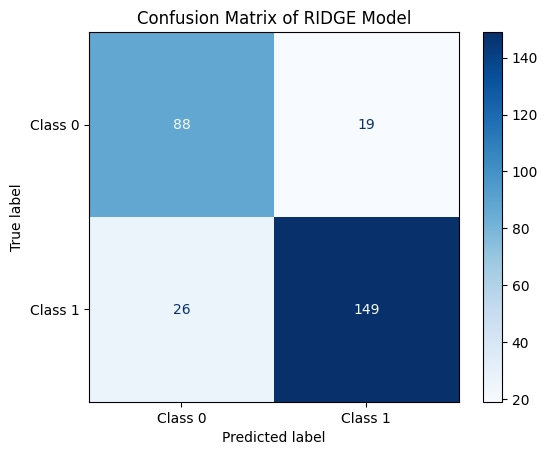

accuracy test =  0.8404255319148937
precision test =  0.8869047619047619
recall test =  0.8514285714285714
f1 test =  0.8688046647230321


In [ ]:
# Convert results in binary classes by a classification treshold
threshold = 0.5  # Standard Treshold
y_pred3 = (y_prob_ridge >= threshold).astype(int)  # Binary classification

# Confusion Metrix
cm = confusion_matrix(y_test_fold, y_pred3)

# Matrix component extraction
tn, fp, fn, tp = cm.ravel()  # TN, FP, FN, TP

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"True Negative (TN): {tn}")
print(f"False Negative (FN): {fn}")

# Grafic Visualization of Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix of RIDGE Model")
plt.show()

print("accuracy test = " , accuracy_score(y_test_fold, y_pred3))
print("precision test = " , precision_score(y_test_fold, y_pred3))
print("recall test = " , recall_score(y_test_fold, y_pred3))
print("f1 test = " , f1_score(y_test_fold, y_pred3))

The improvement was already minimal on the train set, so on the on test set it's complitely absent making the RIDGE Regression completely identical to the first Logit Regression.
Now we will observe ho the LASSO Regression goes

In [ ]:
# Modello Ridge Logistic Regression
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0)
lasso_model.fit(x_logit, y_train_fold)


LogisticRegression(penalty='l1', solver='liblinear')

In [ ]:
# Prediction with the first model
y_prob_lasso = lasso_model.predict(x_logit)

# Derive ROC Curve
fpr4, tpr4, _ = roc_curve(y_train_fold, y_prob_lasso)
roc_auc4 = auc(fpr4, tpr4)

Confusion Matrix:
[[339  89]
 [ 94 602]]

True Positive (TP): 602
False Positive (FP): 89
True Negative (TN): 339
False Negative (FN): 94


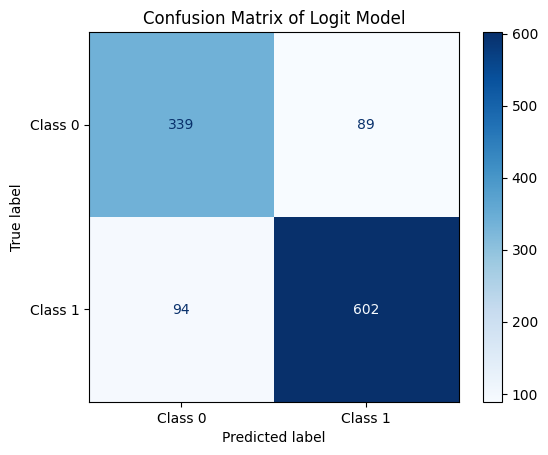

accuracy test =  0.8371886120996441
precision test =  0.8712011577424024
recall test =  0.8649425287356322
f1 test =  0.8680605623648161


In [ ]:
# Convert results in binary classes by a classification treshold
threshold = 0.5  # Standard Treshold
y_pred4 = (y_prob_lasso >= threshold).astype(int)  # Binary classification

# Confusion Metrix
cm = confusion_matrix(y_train_fold, y_pred4)

# Matrix component extraction
tn, fp, fn, tp = cm.ravel()  # TN, FP, FN, TP

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"True Negative (TN): {tn}")
print(f"False Negative (FN): {fn}")

# Grafic Visualization of Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix of Logit Model")
plt.show()

print("accuracy test = " , accuracy_score(y_train_fold, y_pred4))
print("precision test = " , precision_score(y_train_fold, y_pred4))
print("recall test = " , recall_score(y_train_fold, y_pred4))
print("f1 test = " , f1_score(y_train_fold, y_pred4))

In the same way that RIDGE regression was better just for one more True Positive, the LASSO regression is worse because it has one less True Positive than the original model.

In [ ]:
# Prediction with the first model
y_prob_lasso = lasso_model.predict(x_test)

# Derive ROC Curve
fpr4, tpr4, _ = roc_curve(y_test_fold, y_prob_lasso)
roc_auc3 = auc(fpr4, tpr4)

Confusion Matrix:
[[ 88  19]
 [ 26 149]]

True Positive (TP): 149
False Positive (FP): 19
True Negative (TN): 88
False Negative (FN): 26


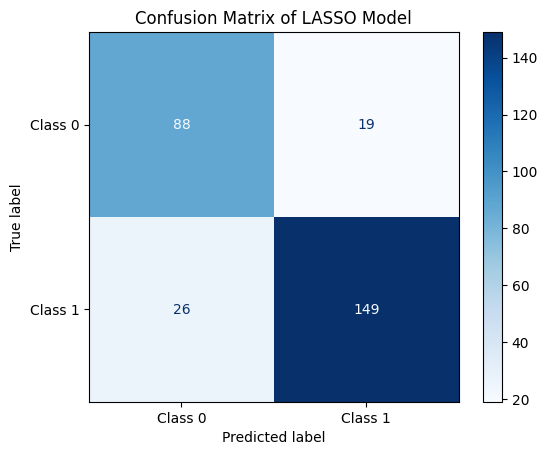

accuracy test =  0.8404255319148937
precision test =  0.8869047619047619
recall test =  0.8514285714285714
f1 test =  0.8688046647230321


In [ ]:
# Convert results in binary classes by a classification treshold
threshold = 0.5  # Standard Treshold
y_pred4 = (y_prob_lasso >= threshold).astype(int)  # Binary classification

# Confusion Metrix
cm = confusion_matrix(y_test_fold, y_pred4)

# Matrix component extraction
tn, fp, fn, tp = cm.ravel()  # TN, FP, FN, TP

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Positive (TP): {tp}")
print(f"False Positive (FP): {fp}")
print(f"True Negative (TN): {tn}")
print(f"False Negative (FN): {fn}")

# Grafic Visualization of Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix of LASSO Model")
plt.show()

print("accuracy test = " , accuracy_score(y_test_fold, y_pred4))
print("precision test = " , precision_score(y_test_fold, y_pred4))
print("recall test = " , recall_score(y_test_fold, y_pred4))
print("f1 test = " , f1_score(y_test_fold, y_pred4))

Just like the RIDGE regression, the LASSO Regression on the test set loses the already small change that he had before.

In conlusion the RIDGE Logit Regression is the best model between all of them, even if for a small margin, and it would probably be better for a bigger dataset and does a pretty good prediction on the target variable.

## Model 2: Decision Tree

### Introduction to the Decision Tree Method

The **Decision Tree** is a supervised machine learning method particularly suited for both classification and regression tasks. It is a non-parametric, distribution-free approach, widely applied across various domains such as medicine, genetics, finance, and marketing. In addition to its predictive capabilities, decision trees serve as an intuitive tool for exploring and understanding data, thanks to their clear and easily interpretable graphical structure.

A decision tree works by recursively partitioning the dataset into increasingly simple and homogeneous subsets with respect to the target variable. At each node, a "question" is posed—a splitting rule based on the predictors—that divides the data into two groups. This process continues until reaching the terminal nodes, or leaves, where a specific value or class of the target variable is assigned.

One of the key aspects of decision trees is the criterion used to determine the splits, or the questions that best divide the data. These decisions are guided by impurity measures, such as the Gini index or entropy, which assess how well a split improves the homogeneity of the resulting groups with respect to the target variable. This approach enables the model to identify the most relevant predictors while automatically discarding less significant ones.

Decision trees offer several advantages. First, they are highly interpretable and they can handle both categorical and numerical data seamlessly, making them versatile across different types of datasets. Moreover, decision trees perform automatic feature selection, focusing on the most important predictors while disregarding irrelevant ones.

In our project, the decision tree proved to be an ideal tool for analyzing the factors influencing the onset of osteoporosis. Its ability to visually and intuitively represent the relationships between predictors and the target variable makes it particularly valuable in medical research.




### Description of the Decision Tree Optimization and Evaluation Process

In this project, we implemented a structured process to optimize and evaluate a **Decision Tree Classifier** using a combination of Grid Search and Cross-Validation. The main goal was to identify the hyperparameter configuration that maximizes the model's performance in terms of accuracy, while ensuring robustness and generalizability.

#### Defining the Parameter Grid

We defined a parameter grid containing some of the most relevant settings for a decision tree. These include:
- The **splitting criterion** ("gini" or "entropy"), which determines how the quality of a split is evaluated at each node.
- The **maximum depth** of the tree (`max_depth`), a key parameter to control model complexity.
- The minimum number of samples required to split a node (`min_samples_split`) and the minimum number of samples required in a leaf node (`min_samples_leaf`), which influence the granularity of the splits.

Defining this grid allows us to explore different parameter combinations and find the optimal one for our data.

#### Creating the Classifier and Stratified K-Fold Cross-Validation

To ensure reliable results, we used a **Stratified K-Fold Cross-Validation** strategy with 5 folds. This approach splits the data into five subsets while maintaining the proportional distribution of classes, thus avoiding biases in the results. This technique is particularly useful for classification problems where imbalanced classes can distort model performance.

We then initialized the tree Classifier with a fixed `random_state`, ensuring reproducibility of the training process across different runs. Since our target variable (i.e., whether a diagnosis of osteoporosis is present or not) is moderately imbalanced, the parameter class_weight = 'balanced' was added.
The class_weight='balanced' option automatically adjusts the weights assigned to each class inversely proportional to their frequencies in the dataset. This ensures that the model pays equal attention to both the minority and majority classes.


#### Optimization with Grid Search

To find the best parameter combination, we used **Grid Search**, which systematically evaluates each combination in the grid by training and validating the model on each fold of the Cross-Validation. This process not only identifies the configuration that maximizes the average accuracy but also provides a measure of performance variability through the standard deviation calculated across the folds.

Grid Search was configured to use all CPU cores, optimizing computational efficiency. Recall was chosen as the primary metric to evaluate model performance, as it is particularly important for medical datasets. Prioritizing recall helps minimize the number of false negatives, which are the most dangerous outcomes in the medical domain.

#### Evaluating the Final Model

After identifying the best parameter set, the optimal model was tested on the test data from one of the folds to estimate its performance on unseen data..



In [ ]:
 # Define the parameter grid for the Decision Tree
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],  # Limit tree depth
    'min_samples_split': [5, 10, 20],  # Ensure splits have sufficient data
    'min_samples_leaf': [5, 10, 20],  # Ensure leaves have sufficient data
    'max_features': [None, 'sqrt', 'log2']  # Regularize feature usage
}

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Configure Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configure GridSearchCV with Cross-Validation
grid_search = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid,
    scoring='recall',
    cv=skf,
    n_jobs=-1  # Use all CPU cores for parallel computation
)

# Perform Grid Search
grid_search.fit(x, y)

# Output the best results from Grid Search
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best Cross-Validation Score: {grid_search.best_score_}')
print(f'Standard Deviation: {grid_search.cv_results_["std_test_score"][grid_search.best_index_]}')

# Retrieve the best model from Grid Search
best_model = grid_search.best_estimator_

# Calculate performance on the full dataset
test_accuracy = best_model.score(x, y)
print(f'Test Accuracy: {test_accuracy}')


Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best Cross-Validation Score: 0.8875073891625614
Standard Deviation: 0.01823209254687563
Test Accuracy: 0.9359886201991465


In the context of Cross-Validation, the standard deviation (σ\) does not refer to the data itself but rather to the variability in the model's performance across different folds. This value provides a measure of how consistent the results are between the folds.

- **Low standard deviation**: Indicates that the model performs consistently across all folds, suggesting good generalization ability.
- **High standard deviation**: Highlights significant variability in performance between folds, which could imply that the model is sensitive to the data partitioning or that there are imbalances in the class distribution.



### Evaluation

### Description of the Decision Tree Training, Evaluation, and Reporting Process

#### Model Initialization

In this part of the code, the **Decision Tree Classifier** is explicitly initialized with the hyperparameters identified during the previous Grid Search phase, designed to maximize the model's performance.

#### Model Training

The classifier is trained using the `.fit()` method applied to the training data of the current fold. This allows the model to build a tree structure that minimizes entropy at each node, learning the patterns present in the data.

#### Generating Predictions

After training, the model is used to predict the labels of the test fold using the `.predict()` method. The predictions (`y_pred_fold`) are then compared with the actual labels of the test set (`y_test_fold`) to evaluate performance.

#### Evaluation Metrics

The model's performance is analyzed using:
1. **Classification Report**:
   - Provides precision, recall, F1-score, and support for each class, offering a detailed overview of the performance.
2. **Confusion Matrix**:
   - Summarizes correct and incorrect predictions in a tabular format, distinguishing true positives, true negatives, false positives, and false negatives.
3. **Accuracy**:
   - Calculates the proportion of correct predictions, providing a concise and intuitive measure of overall performance.

#### Train vs Test Comparison

The code also evaluates the model's performance on the training data by comparing predictions (`y_pred_train`) with the actual training labels (`y_train_fold`). This helps identify potential signs of overfitting:
- If the model performs significantly better on the training data than on the test data, it might be overfitting to the training set.


In [ ]:
# Split the data into train and test sets


x_train_dt= x_train_fold.copy()
x_test_dt = x_test_fold.copy()
y_train_dt = y_train_fold.copy()
y_test_dt = y_test_fold.copy()

# Train the final model with the best parameters
best_model.fit(x_train_dt, y_train_dt)

# Predict on the test fold
y_pred_fold = best_model.predict(x_test_dt)

# Generate the Classification Report
print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_fold))

# Generate the Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_dt, y_pred_fold))

# Accuracy on the test fold
test_accuracy = accuracy_score(y_test_dt, y_pred_fold)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Compare with training data performance
y_pred_train = best_model.predict(x_train_dt)
train_accuracy = accuracy_score(y_train_dt, y_pred_train)
print(f"Train Accuracy: {train_accuracy:.4f}")



Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       107
           1       0.98      0.91      0.94       175

    accuracy                           0.93       282
   macro avg       0.92      0.94      0.93       282
weighted avg       0.94      0.93      0.93       282


Confusion Matrix:
[[104   3]
 [ 16 159]]
Test Accuracy: 0.9326
Train Accuracy: 0.9297


Confusion Matrix (Absolute Values):
[[104   3]
 [ 16 159]]

Confusion Matrix (Percentages):
Row 1:  ['36.88%', '1.06%']
Row 2:  ['5.67%', '56.38%']


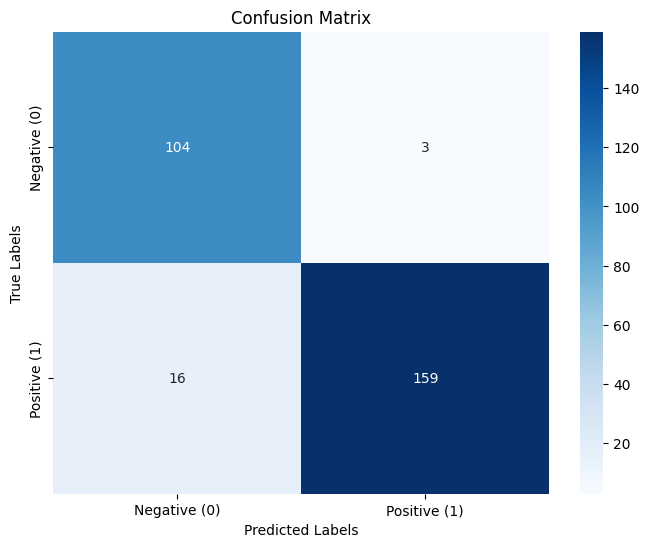

In [ ]:
# Calculate the Confusion Matrix
cm = confusion_matrix(y_test_dt, y_pred_fold)

# Calculate the total number of samples
total_samples = cm.sum()

# Calculate the percentages
percentages = (cm / total_samples) * 100

# Display the confusion matrix with absolute values and percentages
print("Confusion Matrix (Absolute Values):")
print(cm)

print("\nConfusion Matrix (Percentages):")
for i, row in enumerate(percentages):
    print(f"Row {i + 1}: ", [f"{value:.2f}%" for value in row])


# Create a heatmap to represent the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


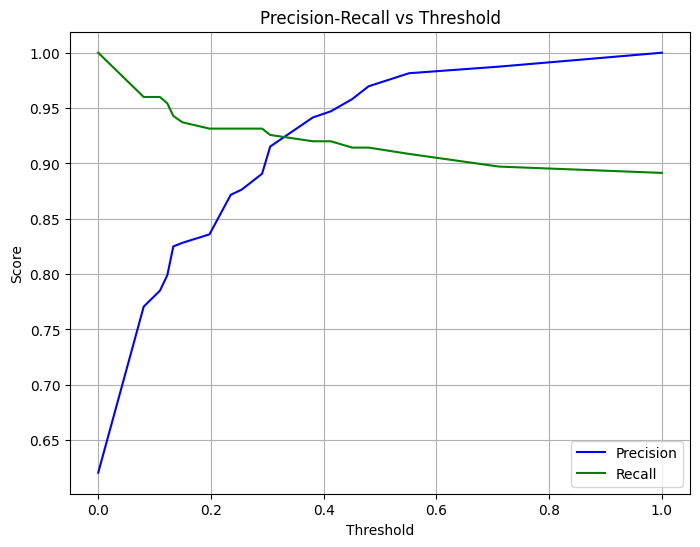

In [ ]:
y_pred_proba = best_model.predict_proba(x_test_dt)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test_dt, y_pred_proba)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label="Precision", color="blue")
plt.plot(thresholds, recall[:-1], label="Recall", color="green")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Choose a threshold based on the desired trade-off
selected_threshold = 0.4


# Apply the selected threshold
y_pred_custom = (y_pred_proba >= selected_threshold).astype(int)


In [ ]:
# Generate the confusion matrix
confusion_matrix_values = confusion_matrix(y_test_dt, y_pred_custom)

# Calculate the total number of samples
total_samples = confusion_matrix_values.sum()

# Calculate the percentages
percentages = (confusion_matrix_values / total_samples) * 100

# Display the confusion matrix with percentages
print("Confusion Matrix (Absolute Values):")
print(confusion_matrix_values)

print("\nConfusion Matrix (Percentages):")
for i, row in enumerate(percentages):
    print(f"Row {i + 1}: ", [f"{value:.2f}%" for value in row])

# Optional: Display classification report for reference
print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_custom))

Confusion Matrix (Absolute Values):
[[ 98   9]
 [ 14 161]]

Confusion Matrix (Percentages):
Row 1:  ['34.75%', '3.19%']
Row 2:  ['4.96%', '57.09%']

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.89       107
           1       0.95      0.92      0.93       175

    accuracy                           0.92       282
   macro avg       0.91      0.92      0.91       282
weighted avg       0.92      0.92      0.92       282



### Tree visualitation

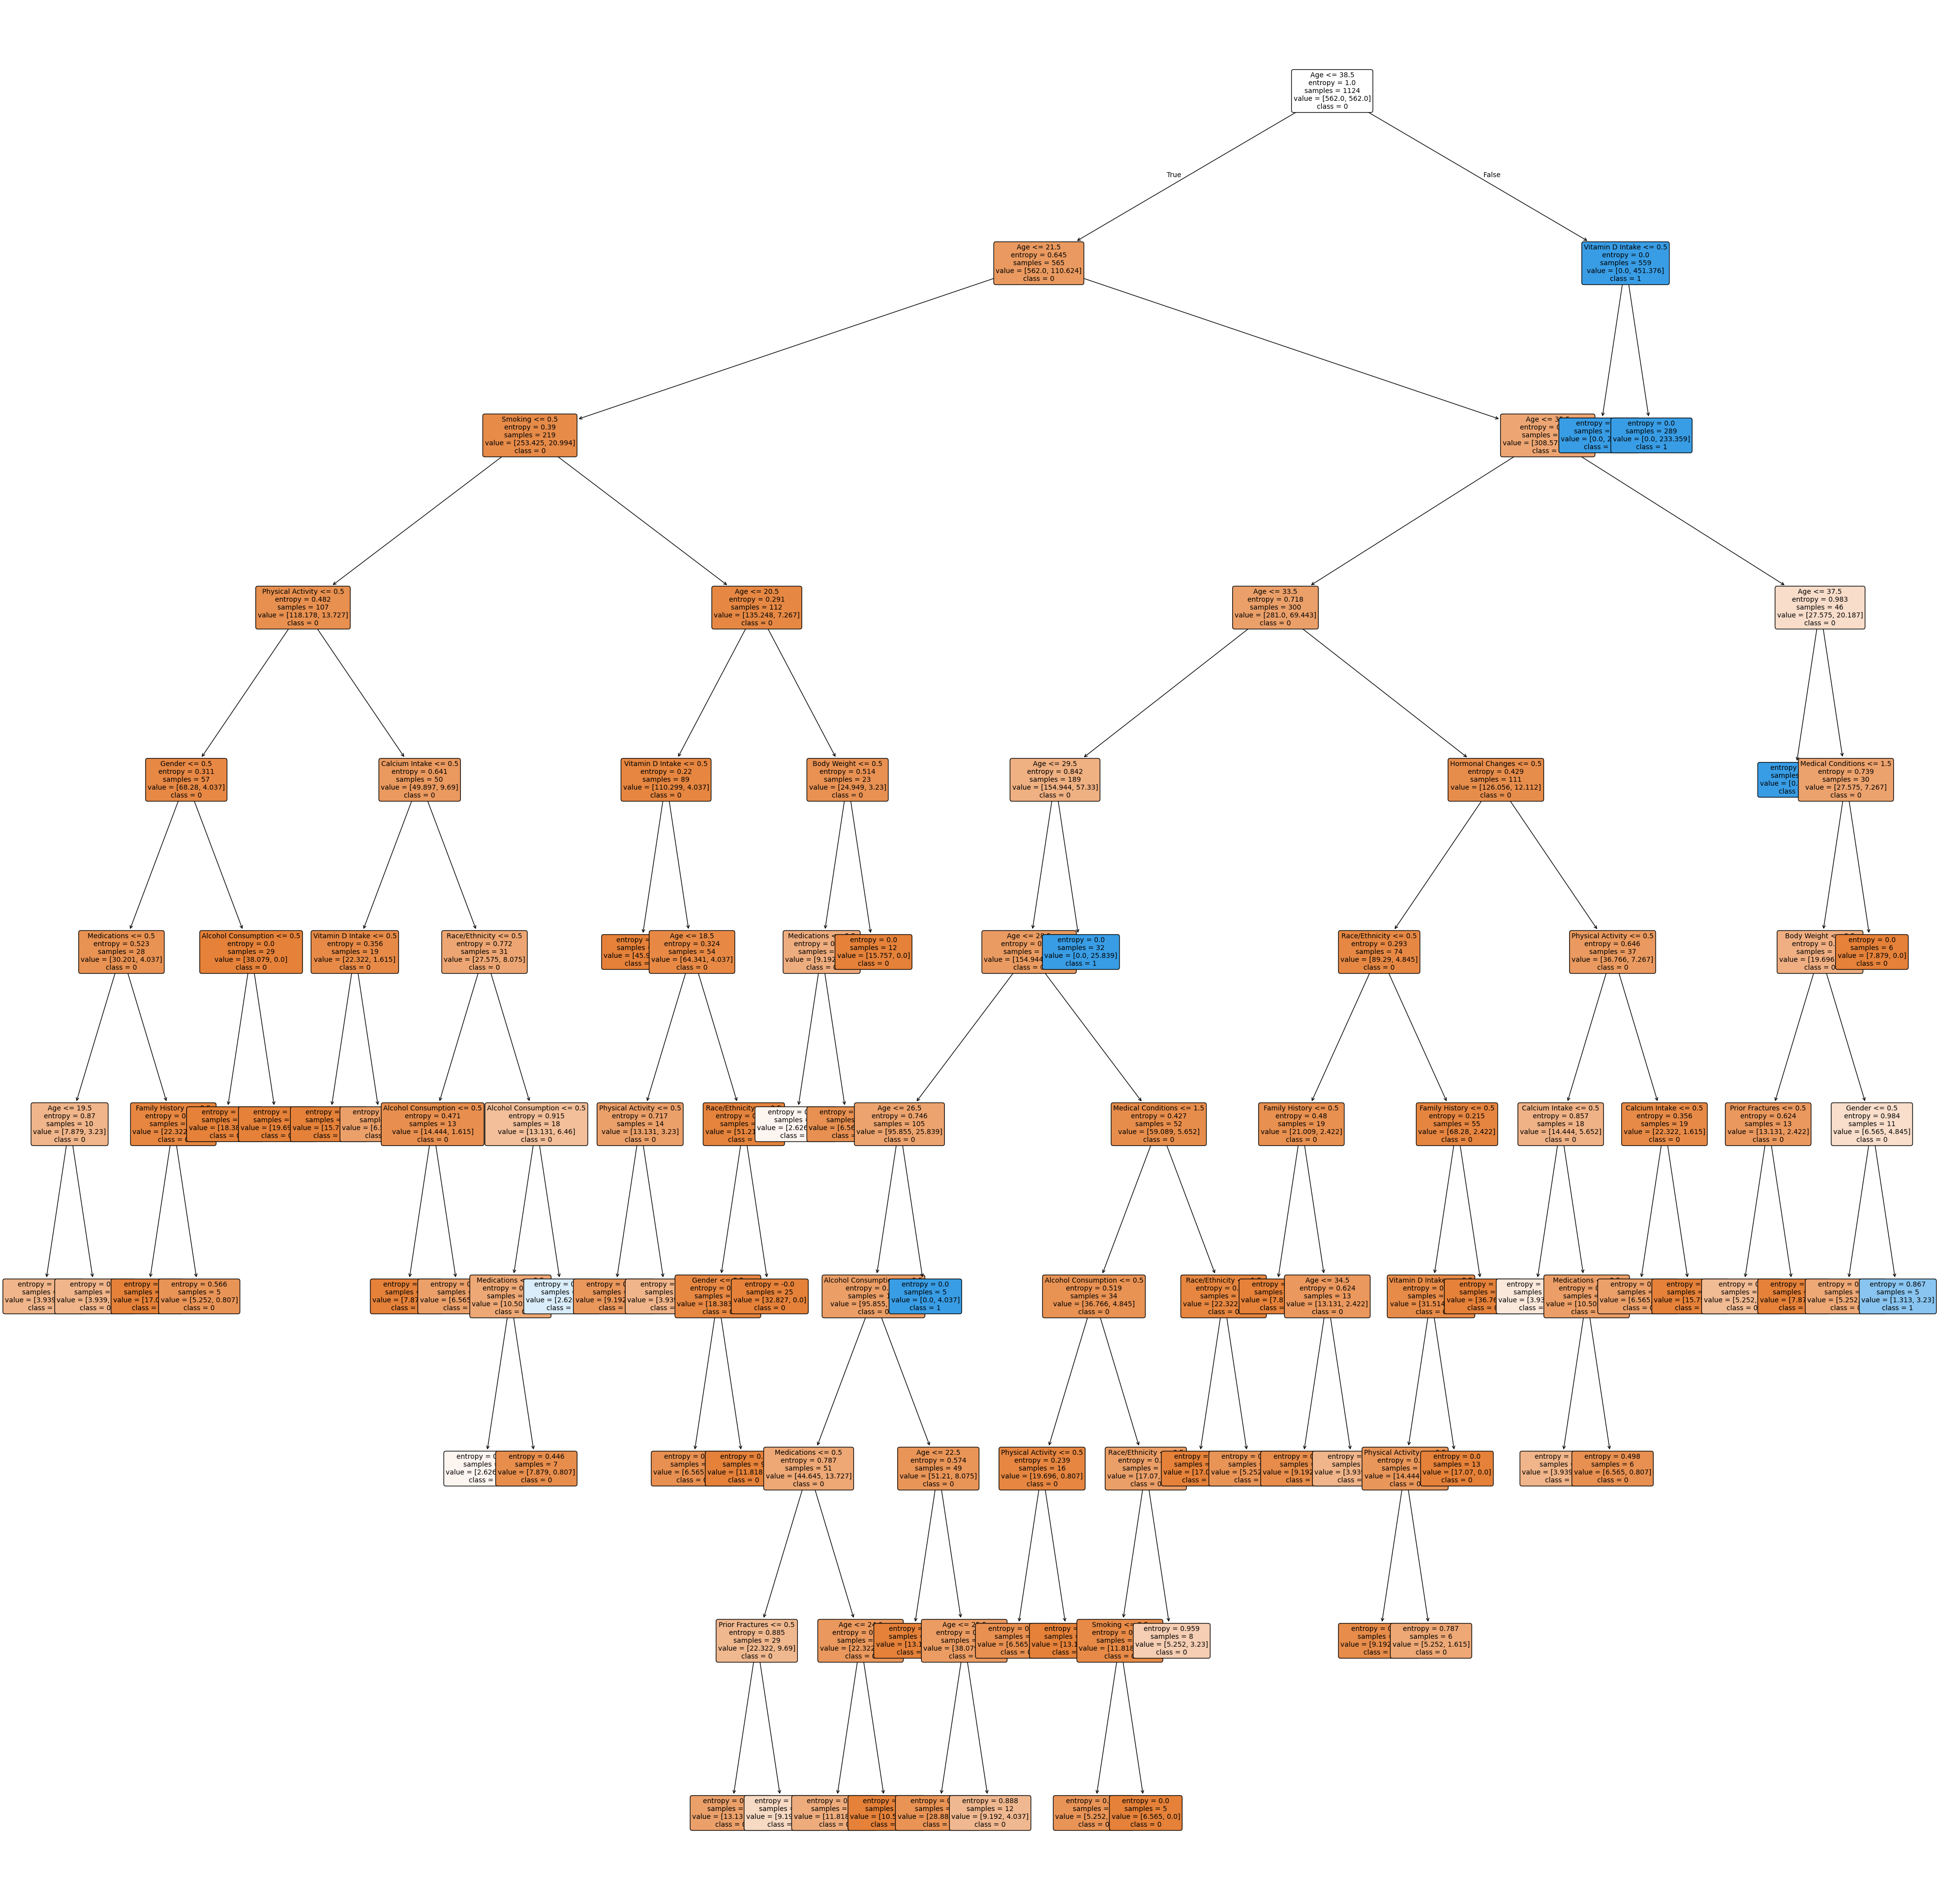

In [ ]:
# Visualize the Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set up the plot
plt.figure(figsize=(50, 50))

# Plot the tree with detailed labels
plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=best_model.classes_.astype(str),  # Convert class labels to string if necessary
    filled=True,  # Use colors to represent the dominant class
    rounded=True,  # Rounded corners for better visualization
    fontsize=10  # Adjust font size for better readability
)

# Show the plot
plt.show()


<ipython-input-70-489a98eee48a>:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




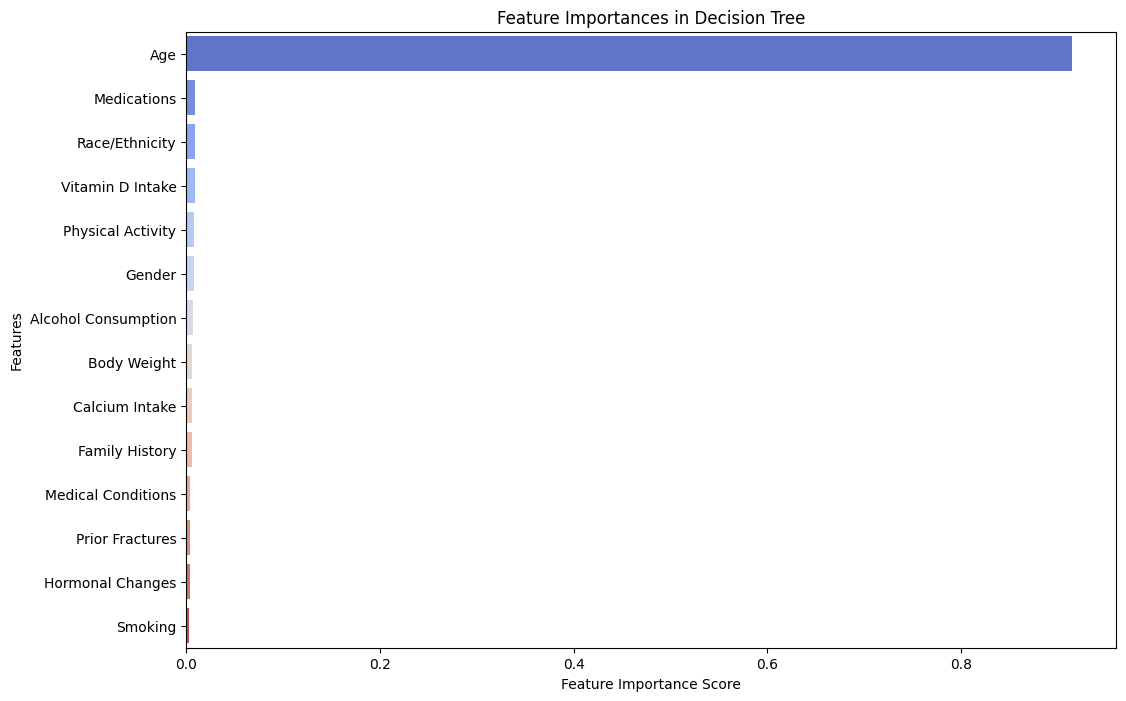

In [ ]:
# Variables to plot feature importance
target_var = 'Osteoporosis'  # Binary target variable
categorical_vars = [
    'Gender', 'Hormonal Changes', 'Family History', 'Calcium Intake',
    'Vitamin D Intake', 'Physical Activity', 'Smoking',
    'Alcohol Consumption', 'Medications', 'Body Weight', 'Prior Fractures',
    'Race/Ethnicity', 'Medical Conditions'
]
numerical_vars = ['Age']

# Feature importance values and names (from Decision Tree)
feature_importances = best_model.feature_importances_  # Use your Decision Tree feature importances
sorted_idx = np.argsort(feature_importances)[::-1]
sorted_feature_names = np.array(x.columns)[sorted_idx]
sorted_importances = feature_importances[sorted_idx]

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Variable': sorted_feature_names,
    'Importance': sorted_importances
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importances
plt.figure(figsize=(12, 8))
sns.barplot(
    x=importance_df['Importance'],
    y=importance_df['Variable'],
    palette='coolwarm'  # Gradient color palette
)
plt.title('Feature Importances in Decision Tree')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()


## Logistic Vs Tree

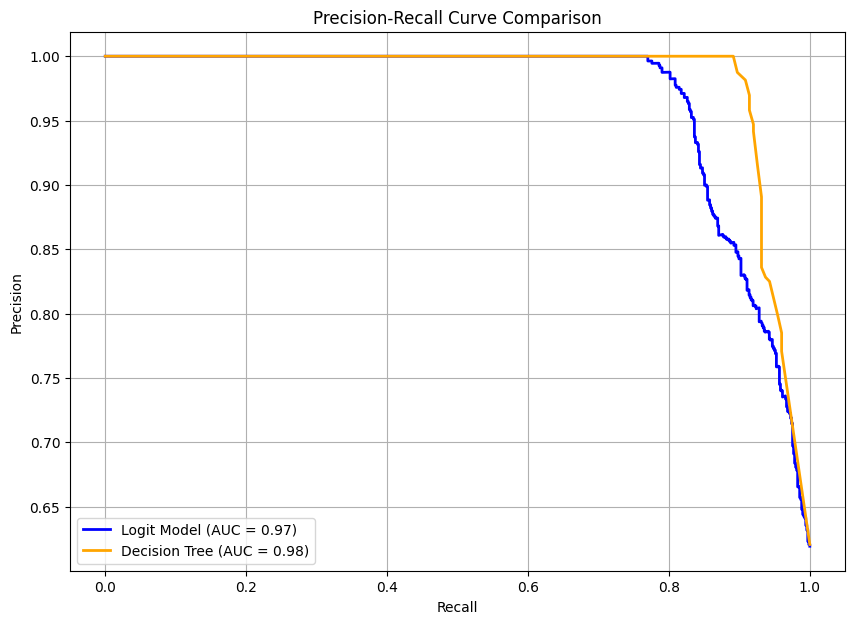

In [ ]:
# Precision-Recall for Logit Model (Logistic Regression)
precision_logit, recall_logit, _ = precision_recall_curve(y_train_fold, y_prob2)
auc_logit = auc(recall_logit, precision_logit)

# Precision-Recall for Decision Tree
y_pred_proba_tree = best_model.predict_proba(x_test_dt)[:, 1]
precision_tree, recall_tree, _ = precision_recall_curve(y_test_dt, y_pred_proba_tree)
auc_tree = auc(recall_tree, precision_tree)

# Plot Precision-Recall curves
plt.figure(figsize=(10, 7))
plt.plot(recall_logit, precision_logit, label=f"Logit Model (AUC = {auc_logit:.2f})", color="blue", linewidth=2)
plt.plot(recall_tree, precision_tree, label=f"Decision Tree (AUC = {auc_tree:.2f})", color="orange", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


### Precision-Recall Curve Analysis

The Precision-Recall curves above compare the performance of two models: **Logit Model** (Logistic Regression) and **Decision Tree**.

1. **Decision Tree**:
   - The Decision Tree achieved an **AUC of 0.98**, reflecting exceptional performance. Its curve remains close to the top-right corner (Precision ≈ 1, Recall ≈ 1) for a large portion of the graph, indicating high precision while maintaining excellent recall.
   - Such strong performance could raise concerns about overfitting. However, with **Train Accuracy (92.97%)** and **Test Accuracy (93.26%)** being nearly identical, this suggests that the Decision Tree generalizes well and is not overfitting. The balanced accuracy values confirm its robustness.

2. **Logit Model**:
   - The Logit Model performed surprisingly well, achieving an **AUC of 0.97**, which is very close to the Decision Tree. The curve shows that the model maintains high precision across a significant range of recall, indicating its ability to capture the underlying patterns in the data effectively.
   - This improvement compared to earlier results suggests that the model's configuration and the dataset's characteristics allow it to perform nearly on par with the Decision Tree, even though it is a simpler, linear model.

3. **Dataset Characteristics**:
   - The high AUC values for both models can likely be attributed to the **artificial nature of the dataset**, which provides clear patterns that both models can leverage effectively. In real-world datasets, with more noise and complexity, the performance gap between the two models might become more pronounced.



----------------------------
- Both the Decision Tree and Logit Model show strong performance on this dataset, with AUC values of 0.98 and 0.97, respectively.
- While the Decision Tree slightly outperforms the Logit Model, the latter's strong results indicate that simpler, interpretable models can also perform exceptionally well in scenarios where the dataset is well-structured and artificial in nature.


# Conclusions

In our study on osteoporosis, we identified that **age** emerges as the most significant factor associated with the condition, to the extent that it overshadows the influence of other variables. This result was consistently observed across all stages of the analysis, including **Exploratory Data Analysis (EDA)**, **logistic regression**, and the **decision tree**. Age, already well-documented in the literature as a key determinant of bone density loss, is reaffirmed here as a critical factor in our dataset.

Secondary factors that also showed a significant contribution include:
1. **Hormonal changes**, such as those associated with menopause, which represent a critical biological transition that accelerates bone density loss.
2. **Corticosteroid use**, known to adversely affect bone metabolism and increase the risk of osteoporosis.

These findings are strongly supported by the scientific literature:
- Age has been identified as a major risk factor for osteoporosis, as described by Prof John A Kanis MD "Diagnosis of osteoporosis and assessment of fracture risk", highlighting the decline in bone mineral density (BMD) and the increased risk of fractures with advanced age. [(Link to article)](https://www.sciencedirect.com/science/article/abs/pii/S0140673602087615)
- The role of hormonal changes, particularly estrogen depletion during menopause, in bone health has been well-documented by Cannarella R, Barbagallo F,et al. in "Osteoporosis from an Endocrine Perspective: The Role of Hormonal Changes in the Elderly". J Clin Med. 2019 Oct 1;8(10):1564. doi: 10.3390/jcm8101564. PMID: 31581477; PMCID: PMC6832998.. (2002)**. [(Link to article)](https://pmc.ncbi.nlm.nih.gov/articles/PMC6832998/)
- The detrimental effects of corticosteroids on bone density have been highlighted by Mitra R. " Adverse effects of corticosteroids on bone metabolism: a review." (PM R. 2011 May;3(5):466-71; quiz 471. doi: 10.1016/j.pmrj.2011.02.017. PMID: 21570035.), emphasizing their contribution to bone fragility. [(Link to article)](https://pubmed.ncbi.nlm.nih.gov/21570035/)

The combined use of statistical methods and machine learning has strengthened the validity of our findings. **Logistic regression** quantified the individual contribution of each variable, while the **decision tree** visually highlighted the dominant role of age in predictive decisions.


------------------------------------------------
### But Don’t Worry About Your Habits!
Interestingly, some of the variables we might think are important—such as **smoking**, **alcohol consumption**, and **vitamin intake**—barely contributed to the predictions of osteoporosis in our analysis. So, at least when it comes to osteoporosis, you can rest easy: skipping your vitamins or indulging in a smoke might not be the end of the world (for your bones, at least!). However, it’s always good to keep in mind their broader health effects!


---------------------------------------------------------------------------

### Implications
These results underline the need for targeted prevention strategies, particularly focused on older populations, and prudent management of corticosteroid use in at-risk patients. Additionally, interventions aimed at monitoring hormonal changes could provide further benefits in managing osteoporosis.
